In [2]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
# import theano.tensor as tt
import pytensor.tensor as tt

from numpy.random import default_rng
from scipy.special import expit as invlogit

In [3]:
%config InlineBackend.figure_format = 'retina'
warnings.simplefilter(action="ignore", category=(FutureWarning, UserWarning))
RANDOM_SEED = 1234
np.random.seed(RANDOM_SEED)
rng = default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")
az.rcParams["stats.hdi_prob"] = 0.89

In [4]:
def standardize(series):
    """Standardize a pandas series"""
    return (series - series.mean()) / series.std()

#### Code 15.1

In [5]:
# Simulate a pancake and return randomly ordered sides
def sim_pancake():
    pancake = rng.integers(3)
    sides = np.array([[1, 1], [1, 0], [0, 0]])[pancake]
    return rng.permutation(sides)


# Simulate 10,000 pancakes
pancakes = np.array([sim_pancake() for i in range(10000)])
up = pancakes[:, 0]
down = pancakes[:, 1]

# Compute proportion 1/1 (BB) out of all 1/1 and 1/0
num_11_10 = np.sum(up == 1)
num_11 = np.sum((up == 1) & (down == 1))
print(f"P(burnt down | burnt up) = {round(num_11 / num_11_10, 2)}")

P(burnt down | burnt up) = 0.66


#### Code 15.2

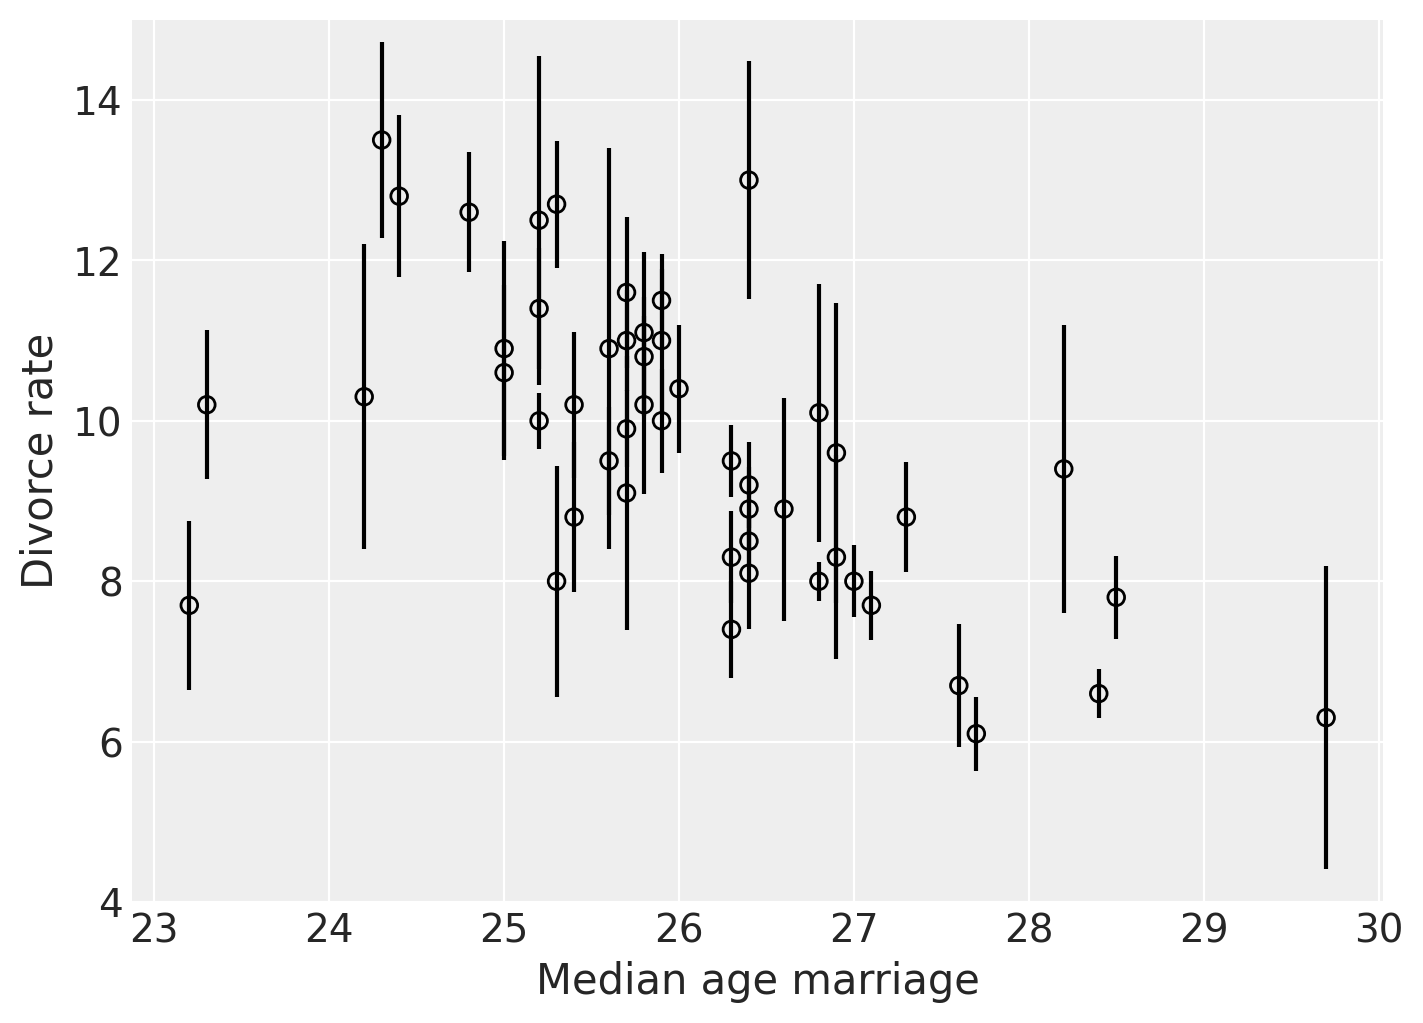

In [8]:
d = pd.read_csv("Data/WaffleDivorce.csv", sep=";")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(d["MedianAgeMarriage"], d["Divorce"], edgecolor="k", facecolor="none")
ax.errorbar(d["MedianAgeMarriage"], d["Divorce"], yerr=d["Divorce SE"], fmt="none", c="k")

ax.set_ylim(4, 15)
ax.set_xlabel("Median age marriage")
ax.set_ylabel("Divorce rate");

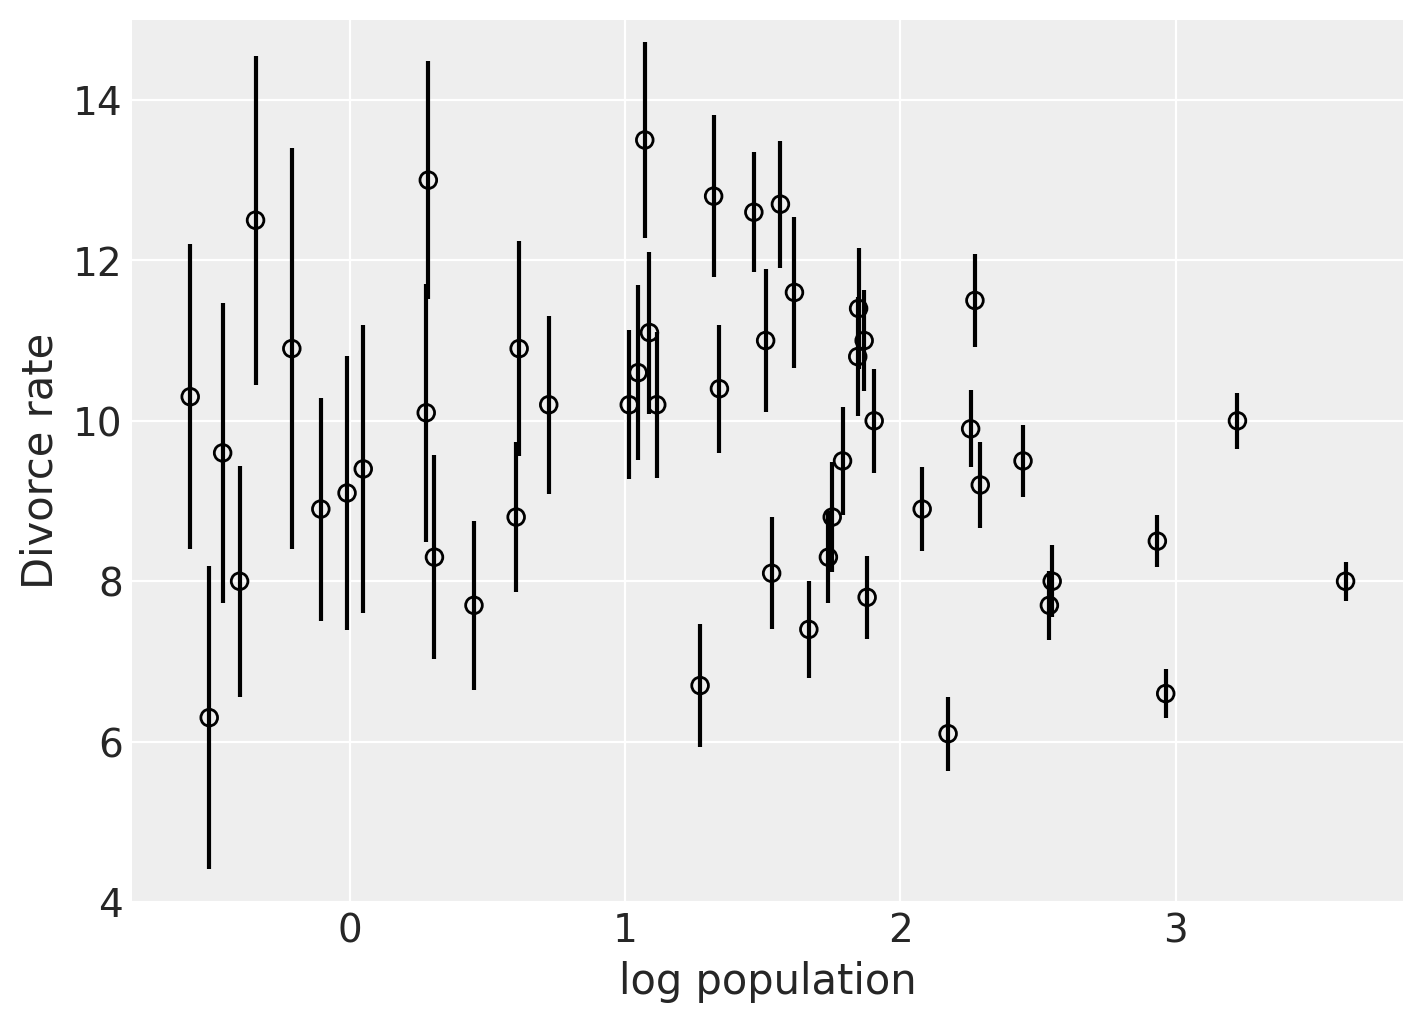

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(np.log(d["Population"]), d["Divorce"], edgecolor="k", facecolor="none")
ax.errorbar(np.log(d["Population"]), d["Divorce"], yerr=d["Divorce SE"], fmt="none", c="k")

ax.set_ylim(4, 15)
ax.set_xlabel("log population")
ax.set_ylabel("Divorce rate");

#### Code 15.3

In [61]:
D_obs = standardize(d["Divorce"])
D_sd = d["Divorce SE"] / d["Divorce"].std()
M = standardize(d["Marriage"])
A = standardize(d["MedianAgeMarriage"])
N = len(d)

with pm.Model() as m15_1:
    sigma = pm.Exponential("sigma", 1)
    bM = pm.Normal("bM", 0, 0.5)
    bA = pm.Normal("bA", 0, 0.5)
    a = pm.Normal("a", 0, 0.2)

    mu = a + bA * A + bM * M  # linear model to assess A -> D
    D_true = pm.Normal("D_true", mu, sigma, shape=N)  # distribution for true values

    D = pm.Normal("D_obs", D_true, D_sd, observed=D_obs)  # distribution for observed values

    idata_m15_1 = pm.sample(return_inferencedata=True, random_seed=RANDOM_SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, bM, bA, a, D_true]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


#### Code 15.4

In [11]:
az.summary(idata_m15_1, var_names=["~D_true"], round_to=2)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bM,0.05,0.17,-0.22,0.31,0.0,0.0,2675.50,2824.99,1.0
bA,-0.61,0.16,-0.85,-0.34,0.0,0.0,2893.51,2849.09,1.0
a,-0.05,0.10,-0.20,0.10,0.0,0.0,3166.65,2652.57,1.0
sigma,0.59,0.11,0.42,0.76,0.0,0.0,1415.52,1500.87,1.0


#### Code 15.5

In [62]:
D_obs = standardize(d["Divorce"])
D_sd = d["Divorce SE"] / d["Divorce"].std()
M_obs = standardize(d["Marriage"])
M_sd = d["Marriage SE"] / d["Marriage"].std()
A = standardize(d["MedianAgeMarriage"])
N = len(d)

with pm.Model() as m15_2:
    sigma = pm.Exponential("sigma", 1)
    bM = pm.Normal("bM", 0, 0.5)
    bA = pm.Normal("bA", 0, 0.5)
    a = pm.Normal("a", 0, 0.2)

    M_true = pm.Normal("M_true", 0, 1, shape=N)  # distribution for true M values
    mu = a + bA * A + bM * M_true  # linear model
    D_true = pm.Normal("D_true", mu, sigma, shape=N)  # distribution for true D values

    D = pm.Normal("D_obs", D_true, D_sd, observed=D_obs)  # distribution for observed D values
    M = pm.Normal("M_obs", M_true, M_sd, observed=M_obs)  # distribution for observed M values

    idata_m15_2 = pm.sample(return_inferencedata=True, random_seed=RANDOM_SEED)

az.summary(idata_m15_2, var_names=["~D_true", "~M_true"], round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, bM, bA, a, M_true, D_true]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bM,0.20,0.21,-0.14,0.53,0.0,0.0,2318.87,2612.11,1.0
bA,-0.55,0.16,-0.79,-0.28,0.0,0.0,3337.59,3573.89,1.0
a,-0.04,0.10,-0.20,0.11,0.0,0.0,4910.79,2967.39,1.0
sigma,0.56,0.11,0.38,0.73,0.0,0.0,1239.25,911.72,1.0


#### Code 15.6

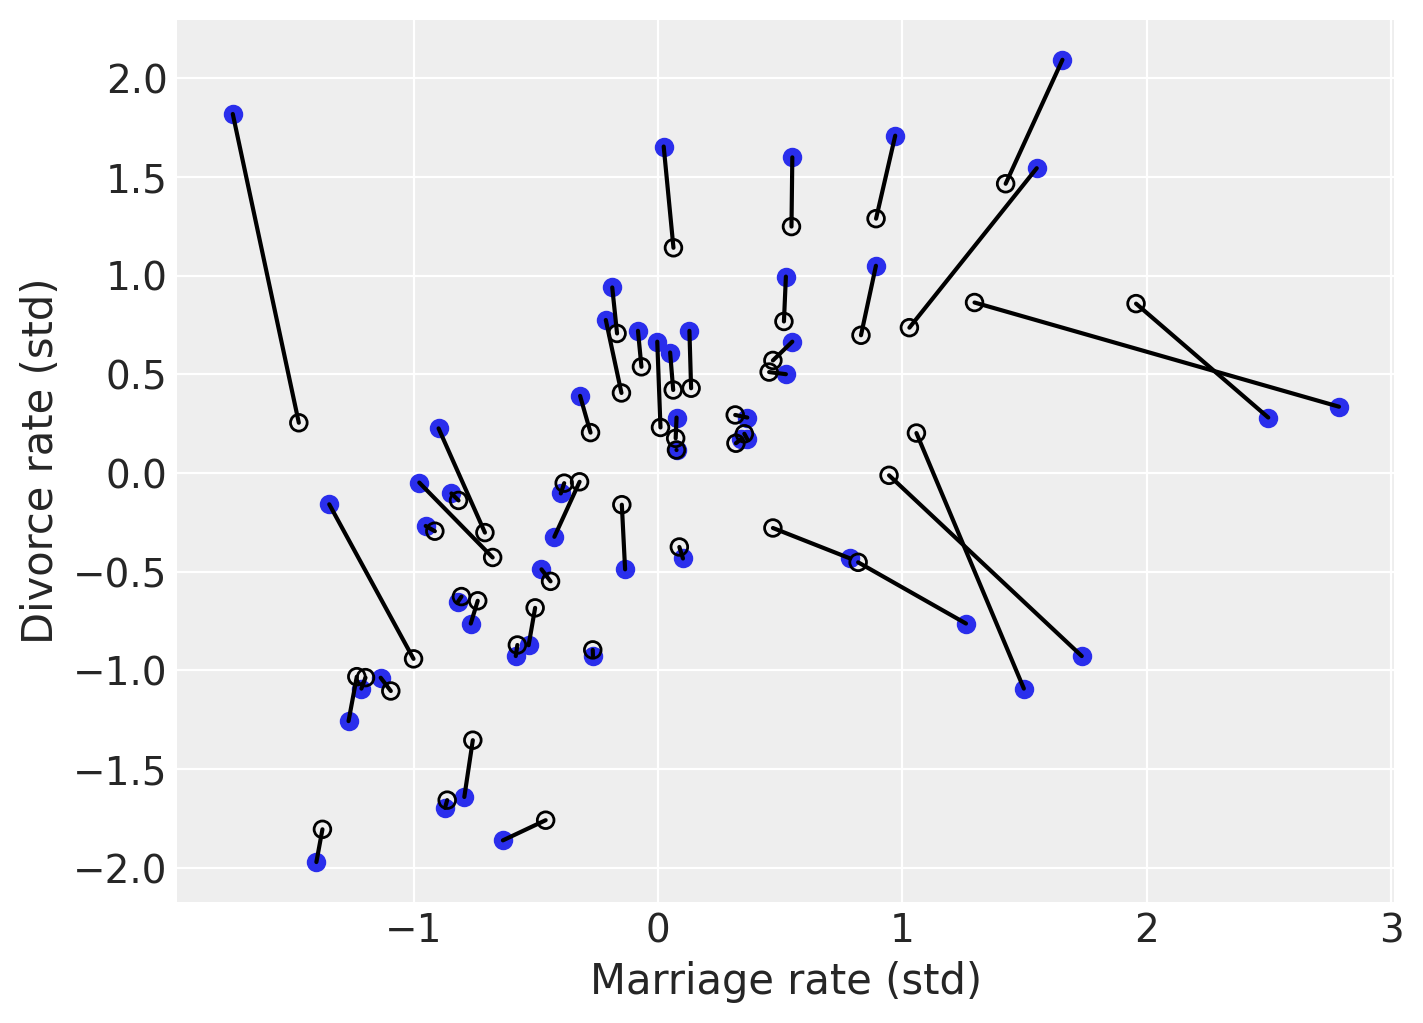

In [15]:
D_true = idata_m15_2.posterior["D_true"].mean(dim=["chain", "draw"])
M_true = idata_m15_2.posterior["M_true"].mean(dim=["chain", "draw"])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(M_obs, D_obs)
ax.scatter(M_true, D_true, edgecolor="k", facecolor="none")
ax.plot([M_obs, M_true], [D_obs, D_true], c="k")

ax.set_xlabel("Marriage rate (std)")
ax.set_ylabel("Divorce rate (std)");

#### Code 15.11

In [16]:
N = 1000  # Number of students
X = rng.normal(size=N)  # Noise of house (unobserved)
S = rng.normal(size=N)  # How much each student studies
H = rng.binomial(
    n=10, p=invlogit(2 + S - 2 * X), size=N
)  # Homework grade affected by study and noise
D = X > 1  # Dogs eat homework in noisy houses

#### Code 15.12

In [17]:
# Model complete dataset

with pm.Model() as m15_3:
    bS = pm.Normal("bS", 0, 0.5)
    a = pm.Normal("a", 0, 1)

    p = pm.invlogit(a + bS * S)  # Model includes study S but not noise X

    Hi = pm.Binomial("Hi", n=10, p=p, observed=H)

    idata_m15_3 = pm.sample(return_inferencedata=True, random_seed=RANDOM_SEED)

# The estimate for bS is biased by the unobserved confound X
az.summary(idata_m15_3, round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [bS, a]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bS,0.6,0.03,0.56,0.64,0.0,0.0,3602.12,2835.33,1.0
a,1.3,0.03,1.26,1.34,0.0,0.0,3616.89,2582.32,1.0


#### Code 15.13

In [18]:
# Model only non-missing data - dogs ate some homework

H_star = H[D == 0]
S_star = S[D == 0]

with pm.Model() as m15_4:
    bS = pm.Normal("bS", 0, 0.5)
    a = pm.Normal("a", 0, 1)

    p = pm.invlogit(a + bS * S_star)

    Hi = pm.Binomial("Hi", n=10, p=p, observed=H_star)

    idata_m15_4 = pm.sample(return_inferencedata=True, random_seed=RANDOM_SEED)

# In this case the estimate for bS is a bit closer to the true value of 1
az.summary(idata_m15_4, round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [bS, a]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bS,0.74,0.03,0.69,0.79,0.0,0.0,2883.45,2675.58,1.0
a,1.91,0.03,1.86,1.97,0.0,0.0,2646.76,2514.68,1.0


#### Code 15.16

In [19]:
d = pd.read_csv("Data/milk.csv", sep=";")
d["neocortex.prop"] = d["neocortex.perc"] / 100
d["logmass"] = np.log(d["mass"])

K = standardize(d["kcal.per.g"])
B = standardize(d["neocortex.prop"])
M = standardize(d["logmass"])

print(f"Number of missing values in B = {np.sum(B.isna())}")

Number of missing values in B = 12


#### Code 15.17

In [20]:
# Impute missing values of B

with pm.Model() as m15_5:
    sigma_B = pm.Exponential("sigma_B", 1)
    sigma = pm.Exponential("sigma", 1)
    bM = pm.Normal("bM", 0, 0.5)
    bB = pm.Normal("bB", 0, 0.5)
    nu = pm.Normal("nu", 0, 0.5)
    a = pm.Normal("a", 0, 0.5)

    # PyMC automatically imputes missing values
    Bi = pm.Normal("Bi", nu, sigma_B, observed=B)

    mu = a + bB * Bi + bM * M

    Ki = pm.Normal("Ki", mu, sigma, observed=K)

    idata_m15_5 = pm.sample(return_inferencedata=True, random_seed=RANDOM_SEED)
az.summary(idata_m15_5, round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_B, sigma, bM, bB, nu, a, Bi_unobserved]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bM,-0.53,0.21,-0.88,-0.22,0.00,0.00,2912.76,3191.44,1.0
bB,0.48,0.24,0.10,0.87,0.01,0.00,2136.29,2693.08,1.0
nu,-0.05,0.21,-0.40,0.28,0.00,0.00,3611.19,2891.25,1.0
a,0.03,0.17,-0.22,0.31,0.00,0.00,6110.82,3221.31,1.0
Bi_unobserved[0],-0.57,0.93,-2.00,0.92,0.01,0.02,4405.98,2841.04,1.0
Bi_unobserved[1],-0.68,0.97,-2.24,0.82,0.02,0.02,4132.35,2394.38,1.0
Bi_unobserved[2],-0.67,0.95,-2.18,0.76,0.01,0.02,4474.57,3248.53,1.0
Bi_unobserved[3],-0.28,0.90,-1.67,1.19,0.01,0.02,6754.87,3156.22,1.0
Bi_unobserved[4],0.43,0.92,-0.93,1.95,0.01,0.02,5073.04,3201.34,1.0
Bi_unobserved[5],-0.17,0.91,-1.52,1.35,0.01,0.01,5882.33,3024.60,1.0


#### Code 15.19

In [21]:
# Model only complete cases for comparison with model 15_5

obs_idx = ~d["neocortex.prop"].isna()
K_obs = K[obs_idx]
B_obs = B[obs_idx]
M_obs = M[obs_idx]

with pm.Model() as m15_6:
    sigma_B = pm.Exponential("sigma_B", 1)
    sigma = pm.Exponential("sigma", 1)
    bM = pm.Normal("bM", 0, 0.5)
    bB = pm.Normal("bB", 0, 0.5)
    nu = pm.Normal("nu", 0, 0.5)
    a = pm.Normal("a", 0, 0.5)

    Bi = pm.Normal("Bi", nu, sigma_B, observed=B_obs)

    mu = a + bB * Bi + bM * M_obs

    Ki = pm.Normal("Ki", mu, sigma, observed=K_obs)

    idata_m15_6 = pm.sample(return_inferencedata=True, random_seed=RANDOM_SEED)
az.summary(idata_m15_6, round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_B, sigma, bM, bB, nu, a]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bM,-0.64,0.24,-1.03,-0.28,0.0,0.0,3032.53,2902.01,1.0
bB,0.61,0.27,0.21,1.07,0.0,0.0,3145.08,2813.54,1.0
nu,-0.00,0.23,-0.36,0.37,0.0,0.0,3846.11,2672.66,1.0
a,0.11,0.20,-0.20,0.41,0.0,0.0,4614.13,2934.52,1.0
sigma_B,1.04,0.20,0.72,1.30,0.0,0.0,3797.13,2897.59,1.0
sigma,0.87,0.18,0.60,1.13,0.0,0.0,3203.56,2654.94,1.0


#### Code 15.20

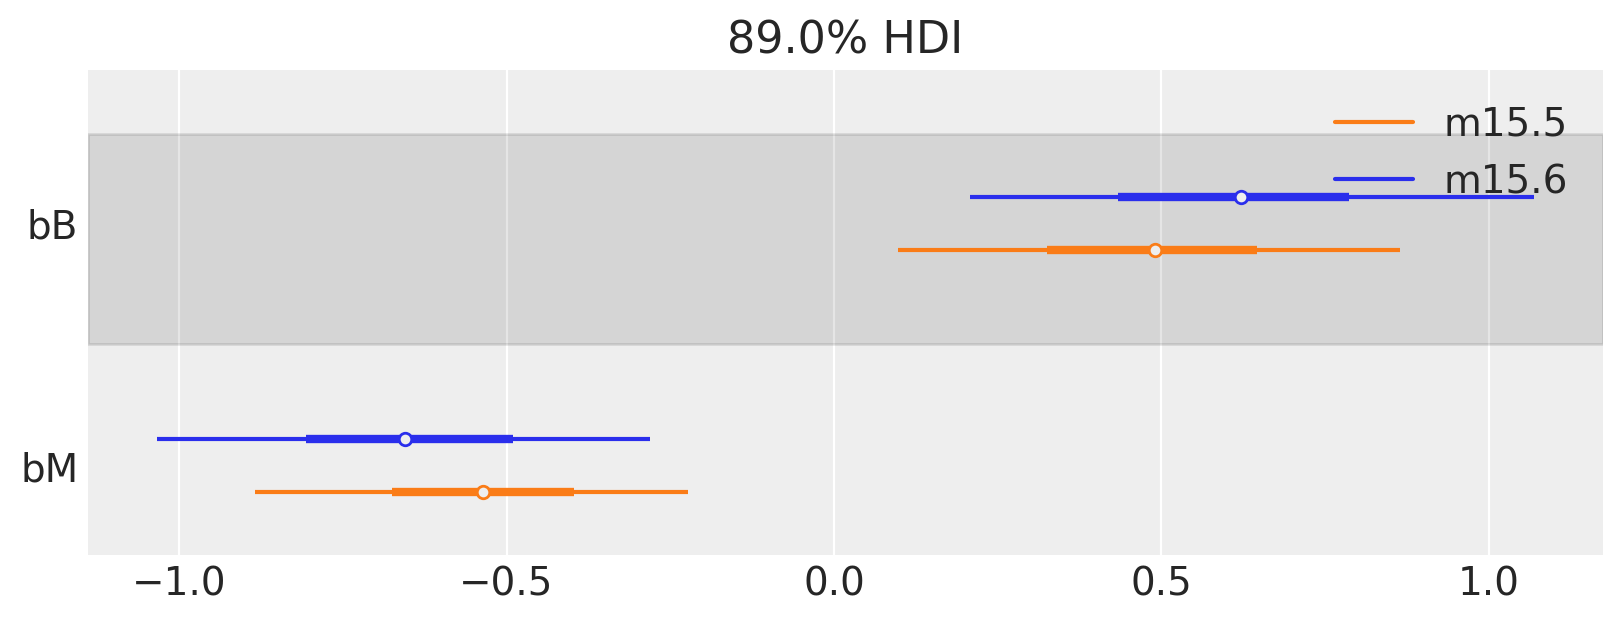

In [22]:
# Model m15.5 (which imputes the missing values) has narrower marginal distributions of bB and bM

az.plot_forest(
    [idata_m15_6, idata_m15_5],
    model_names=["m15.6", "m15.5"],
    var_names=["bB", "bM"],
    combined=True,
    figsize=(8, 3),
);

#### Code 15.21

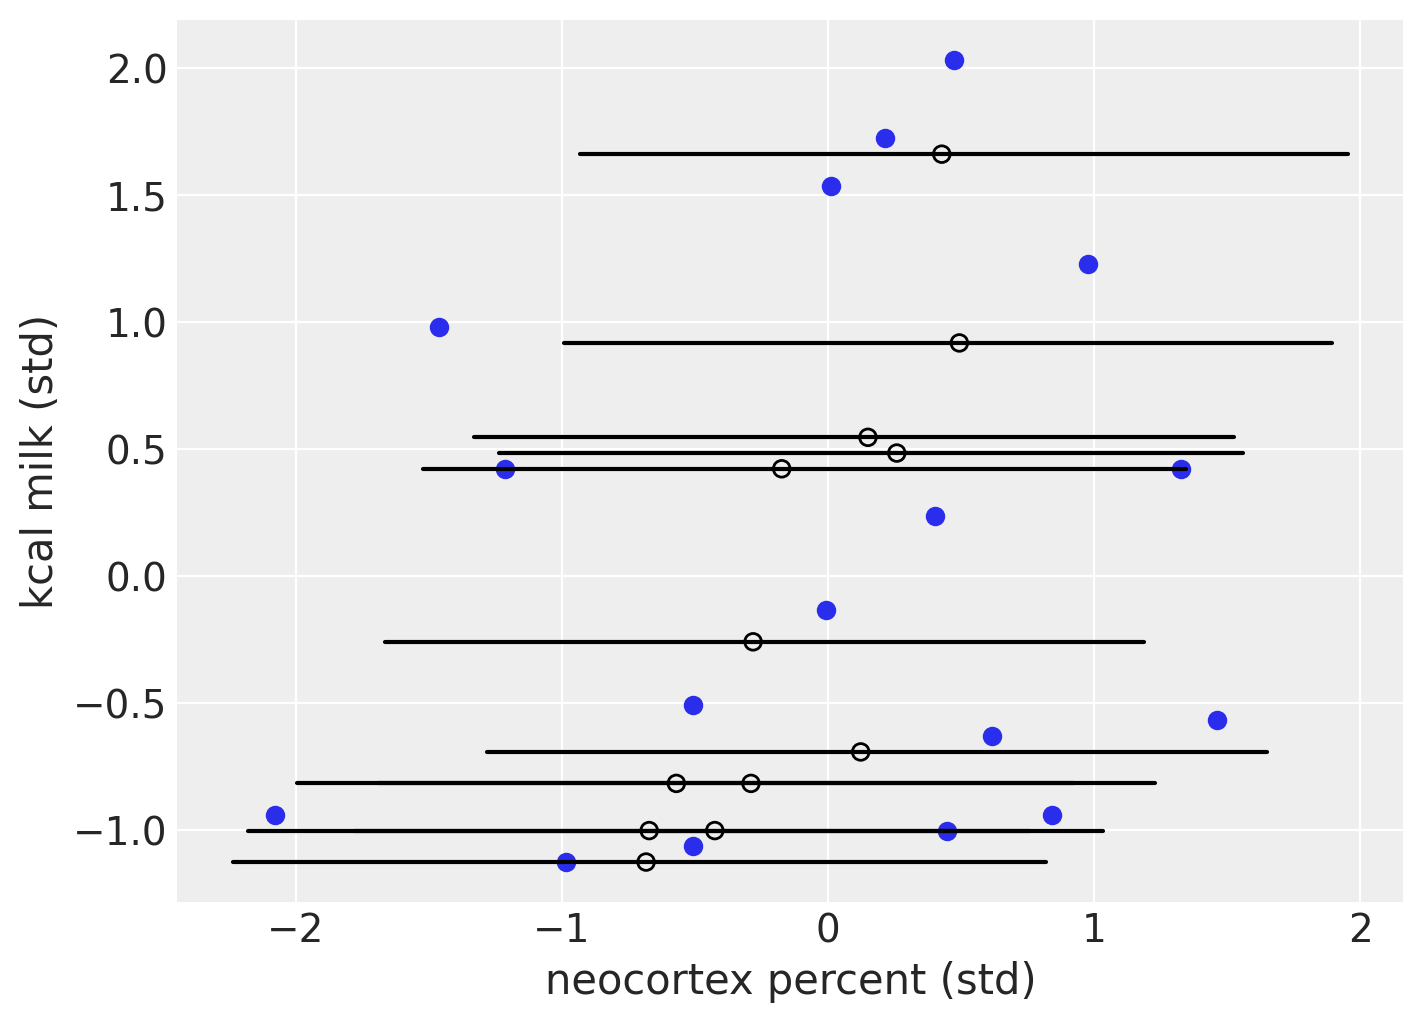

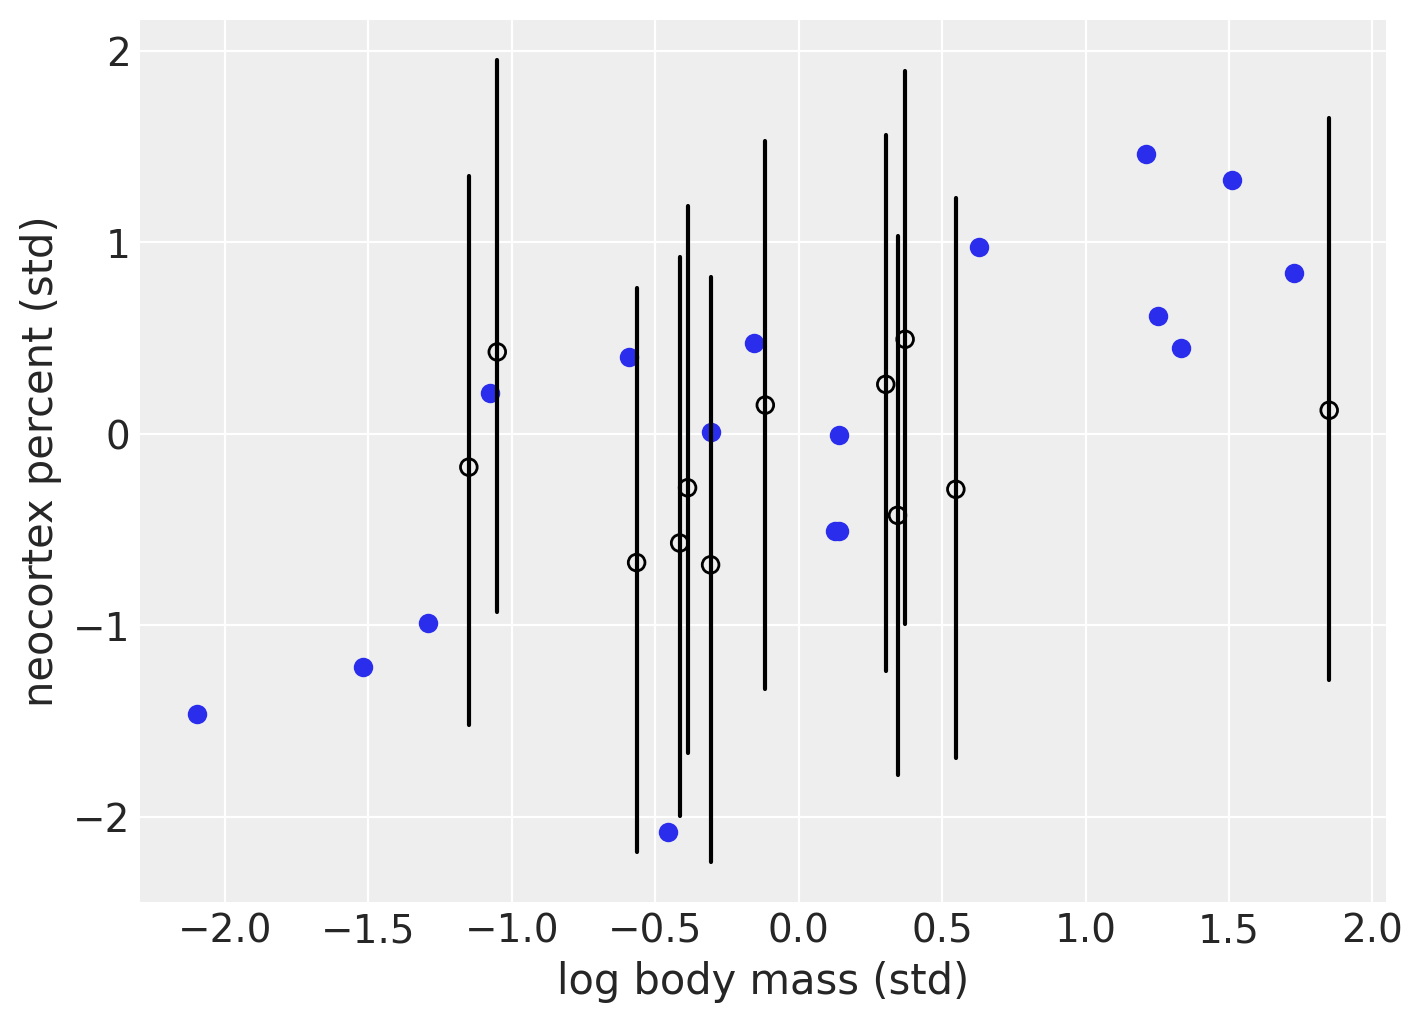

In [26]:
post = idata_m15_5.posterior

# Calculate the posterior mean and hdi for imputed values of B
B_impute_mu = post["Bi_unobserved"].mean(dim=["chain", "draw"])
B_impute_ci = az.hdi(post, var_names=["Bi_unobserved"])["Bi_unobserved"]

# B vs K
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(B, K)
ax.scatter(B_impute_mu, K[~obs_idx], edgecolor="k", facecolor="none")
ax.plot(
    [B_impute_ci.sel(hdi="lower"), B_impute_ci.sel(hdi="higher")],
    [K[~obs_idx], K[~obs_idx]],
    color="k",
)
ax.set_xlabel("neocortex percent (std)")
ax.set_ylabel("kcal milk (std)")

# M vs B
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(M, B)
ax.scatter(M[~obs_idx], B_impute_mu, edgecolor="k", facecolor="none")
ax.plot(
    [M[~obs_idx], M[~obs_idx]],
    [B_impute_ci.sel(hdi="lower"), B_impute_ci.sel(hdi="higher")],
    color="k",
)
ax.set_xlabel("log body mass (std)")
ax.set_ylabel("neocortex percent (std)");

#### Code 15.22

In [27]:
# Include association between M and B

MB_masked = np.ma.masked_invalid(np.stack([M, B]).T)

with pm.Model() as m15_7:
    sigma = pm.Exponential("sigma", 1)
    muM = pm.Normal("muM", 0, 0.5)
    muB = pm.Normal("muB", 0, 0.5)
    bM = pm.Normal("bM", 0, 0.5)
    bB = pm.Normal("bB", 0, 0.5)
    a = pm.Normal("a", 0, 0.5)

    chol, _, _ = pm.LKJCholeskyCov(
        "chol_cov", n=2, eta=2, sd_dist=pm.Exponential.dist(1), compute_corr=True
    )

    # M and B correlation
    MB = pm.MvNormal("MB", mu=tt.stack([muM, muB]), chol=chol, observed=MB_masked)

    mu = a + bB * MB[:, 1] + bM * M

    Ki = pm.Normal("Ki", mu, sigma, observed=K)

    idata_m15_7 = pm.sample(return_inferencedata=True, random_seed=RANDOM_SEED)

idata_m15_7.posterior = idata_m15_7.posterior.rename_vars({"chol_cov_corr": "Rho_MB"})
# Strong correlation between M and B
az.summary(idata_m15_7, var_names=["bM", "bB", "Rho_MB"], round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, muM, muB, bM, bB, a, chol_cov, MB_unobserved]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bM,-0.65,0.22,-1.00,-0.28,0.00,0.0,2793.14,2852.19,1.0
bB,0.59,0.26,0.17,0.98,0.01,0.0,1998.91,2980.00,1.0
"Rho_MB[0, 0]",1.00,0.00,1.00,1.00,0.00,NaN,4000.00,4000.00,NaN
"Rho_MB[0, 1]",0.61,0.13,0.41,0.80,0.00,0.0,2702.53,2644.85,1.0
"Rho_MB[1, 0]",0.61,0.13,0.41,0.80,0.00,0.0,2702.53,2644.85,1.0
"Rho_MB[1, 1]",1.00,0.00,1.00,1.00,0.00,0.0,3882.87,3850.22,1.0


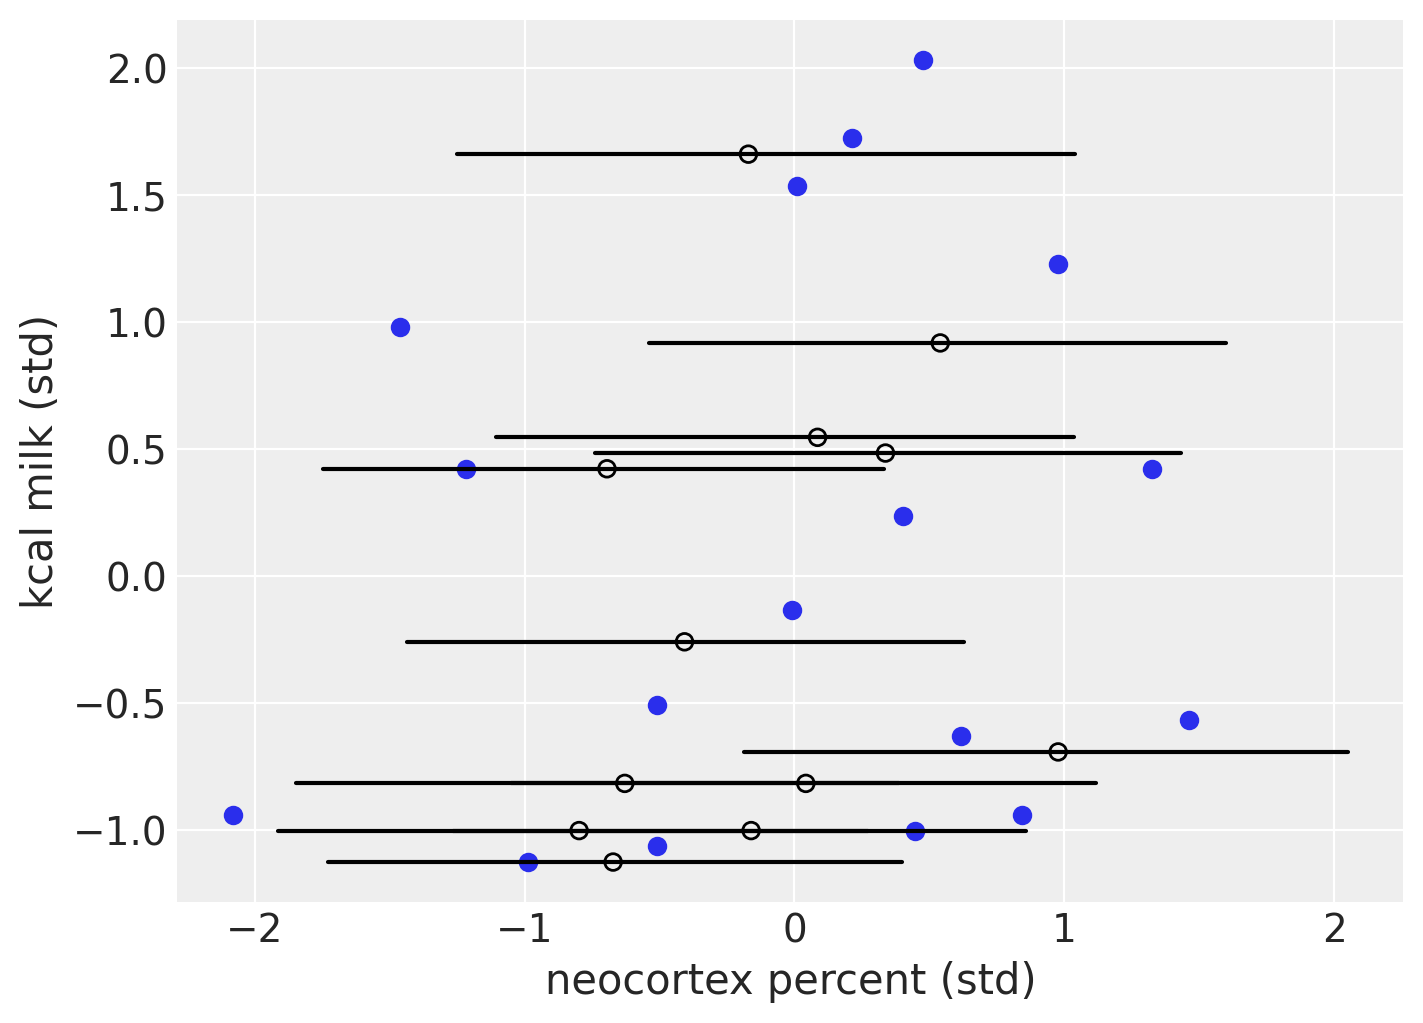

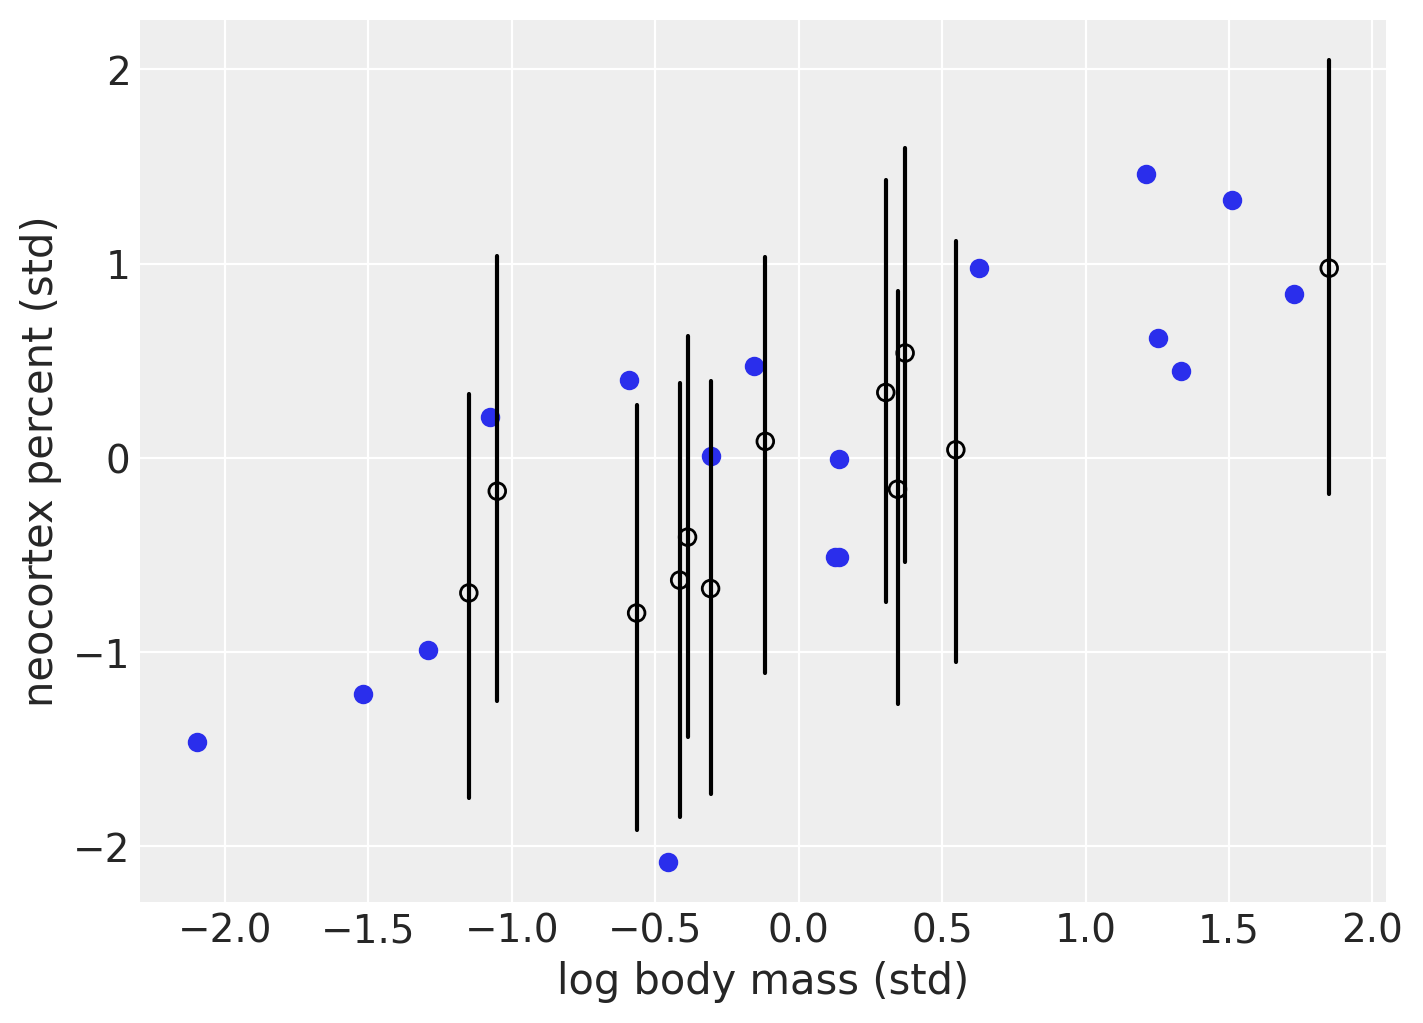

In [30]:
post = idata_m15_7.posterior

# Calculate the posterior mean and hdi for imputed values of B
B_impute_mu = post["MB_unobserved"].mean(dim=["chain", "draw"])
B_impute_ci = az.hdi(post, var_names=["MB_unobserved"])["MB_unobserved"]

# B vs K
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(B, K)
ax.scatter(B_impute_mu, K[~obs_idx], edgecolor="k", facecolor="none")
ax.plot(
    [B_impute_ci.sel(hdi="lower"), B_impute_ci.sel(hdi="higher")],
    [K[~obs_idx], K[~obs_idx]],
    color="k",
)
ax.set_xlabel("neocortex percent (std)")
ax.set_ylabel("kcal milk (std)")

# M vs B
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(M, B)
ax.scatter(M[~obs_idx], B_impute_mu, edgecolor="k", facecolor="none")
ax.plot(
    [M[~obs_idx], M[~obs_idx]],
    [B_impute_ci.sel(hdi="lower"), B_impute_ci.sel(hdi="higher")],
    color="k",
)
ax.set_xlabel("log body mass (std)")
ax.set_ylabel("neocortex percent (std)");

#### Code 15.29

In [31]:
N_houses = 100  # Number of houses to simulate
alpha = 5  # Average number of notes when cat is absent
beta = -3  # Difference in number of notes when cat is present
k_true = 0.5  # Probability of cat present
r = 0.2  # Probability of not knowing whether cat present/absent

cat_true = rng.binomial(n=1, p=k_true, size=N_houses)
notes = rng.poisson(lam=alpha + beta * cat_true, size=N_houses)
R_C = rng.binomial(n=1, p=r, size=N_houses)
cat = cat_true.copy()
cat[R_C == 1] = -9

#### Code 15.30

In [33]:
# with pm.Model() as m15_8:
#     # priors
#     a = pm.Normal("a", 0, 1)
#     b = pm.Normal("b", 0, 0.5)
#     k = pm.Beta("k", 2, 2)

#     # cat NA
#     custom_logp = pm.math.logsumexp(
#         pm.math.log(k)
#         + pm.Poisson.dist(pm.math.exp(a + b)).logp(notes[cat == -9])
#         + pm.math.log(1 - k)
#         + pm.Poisson.dist(pm.math.exp(a)).logp(notes[cat == -9])
#     )
#     # Using pm.Potential to add custom term to model logp
#     notes_RC_1 = pm.Potential("notes|RC==1", custom_logp)

#     # cat known present/absent
#     cat_RC_0 = pm.Bernoulli("cat|RC==0", k, observed=cat[cat != -9])
#     lam = pm.math.exp(a + b * cat_RC_0)
#     notes_RC_0 = pm.Poisson("notes|RC==0", lam, observed=notes[cat != -9])

#     idata_m15_8 = pm.sample(return_inferencedata=True, random_seed=RANDOM_SEED)
# az.summary(idata_m15_8, var_names=["a", "b", "k"], round_to=2)

with pm.Model() as m15_8:
    # Priors
    a = pm.Normal("a", 0, 1)
    b = pm.Normal("b", 0, 0.5)
    k = pm.Beta("k", 2, 2)

    # Separate indices for known and unknown categories
    idx_known = cat != -9
    idx_unknown = cat == -9

    # --- Model for missing categories as a Poisson mixture ---
    mu1 = pm.math.exp(a + b)
    mu2 = pm.math.exp(a)
    y = notes[idx_unknown]

    logp_mixture = pm.math.logaddexp(
        pm.math.log(k) + pm.logp(pm.Poisson.dist(mu=mu1), y),
        pm.math.log(1 - k) + pm.logp(pm.Poisson.dist(mu=mu2), y),
    )

    # Add custom logp to the model
    pm.Potential("notes_RC_1", logp_mixture)

    # --- Model for known categories ---
    cat_RC_0 = pm.Bernoulli("cat_RC_0", k, observed=cat[idx_known])
    lam = pm.math.exp(a + b * cat_RC_0)
    notes_RC_0 = pm.Poisson("notes_RC_0", lam, observed=notes[idx_known])

    idata_m15_8 = pm.sample(return_inferencedata=True, random_seed=RANDOM_SEED)
az.summary(idata_m15_8, var_names=["a", "b", "k"], round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, k]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.59,0.06,1.49,1.69,0.0,0.0,3251.06,2766.74,1.0
b,-0.94,0.12,-1.13,-0.73,0.0,0.0,3265.75,2640.27,1.0
k,0.47,0.05,0.39,0.55,0.0,0.0,4466.33,3012.25,1.0


In [34]:
print(f"a from data generating process = {round(np.log(alpha), 2)}")
print(f"b from data generating process = {round(np.log(alpha+beta)-np.log(alpha), 2)}")
print(f"k from data generating process = {k_true}")

a from data generating process = 1.61
b from data generating process = -0.92
k from data generating process = 0.5


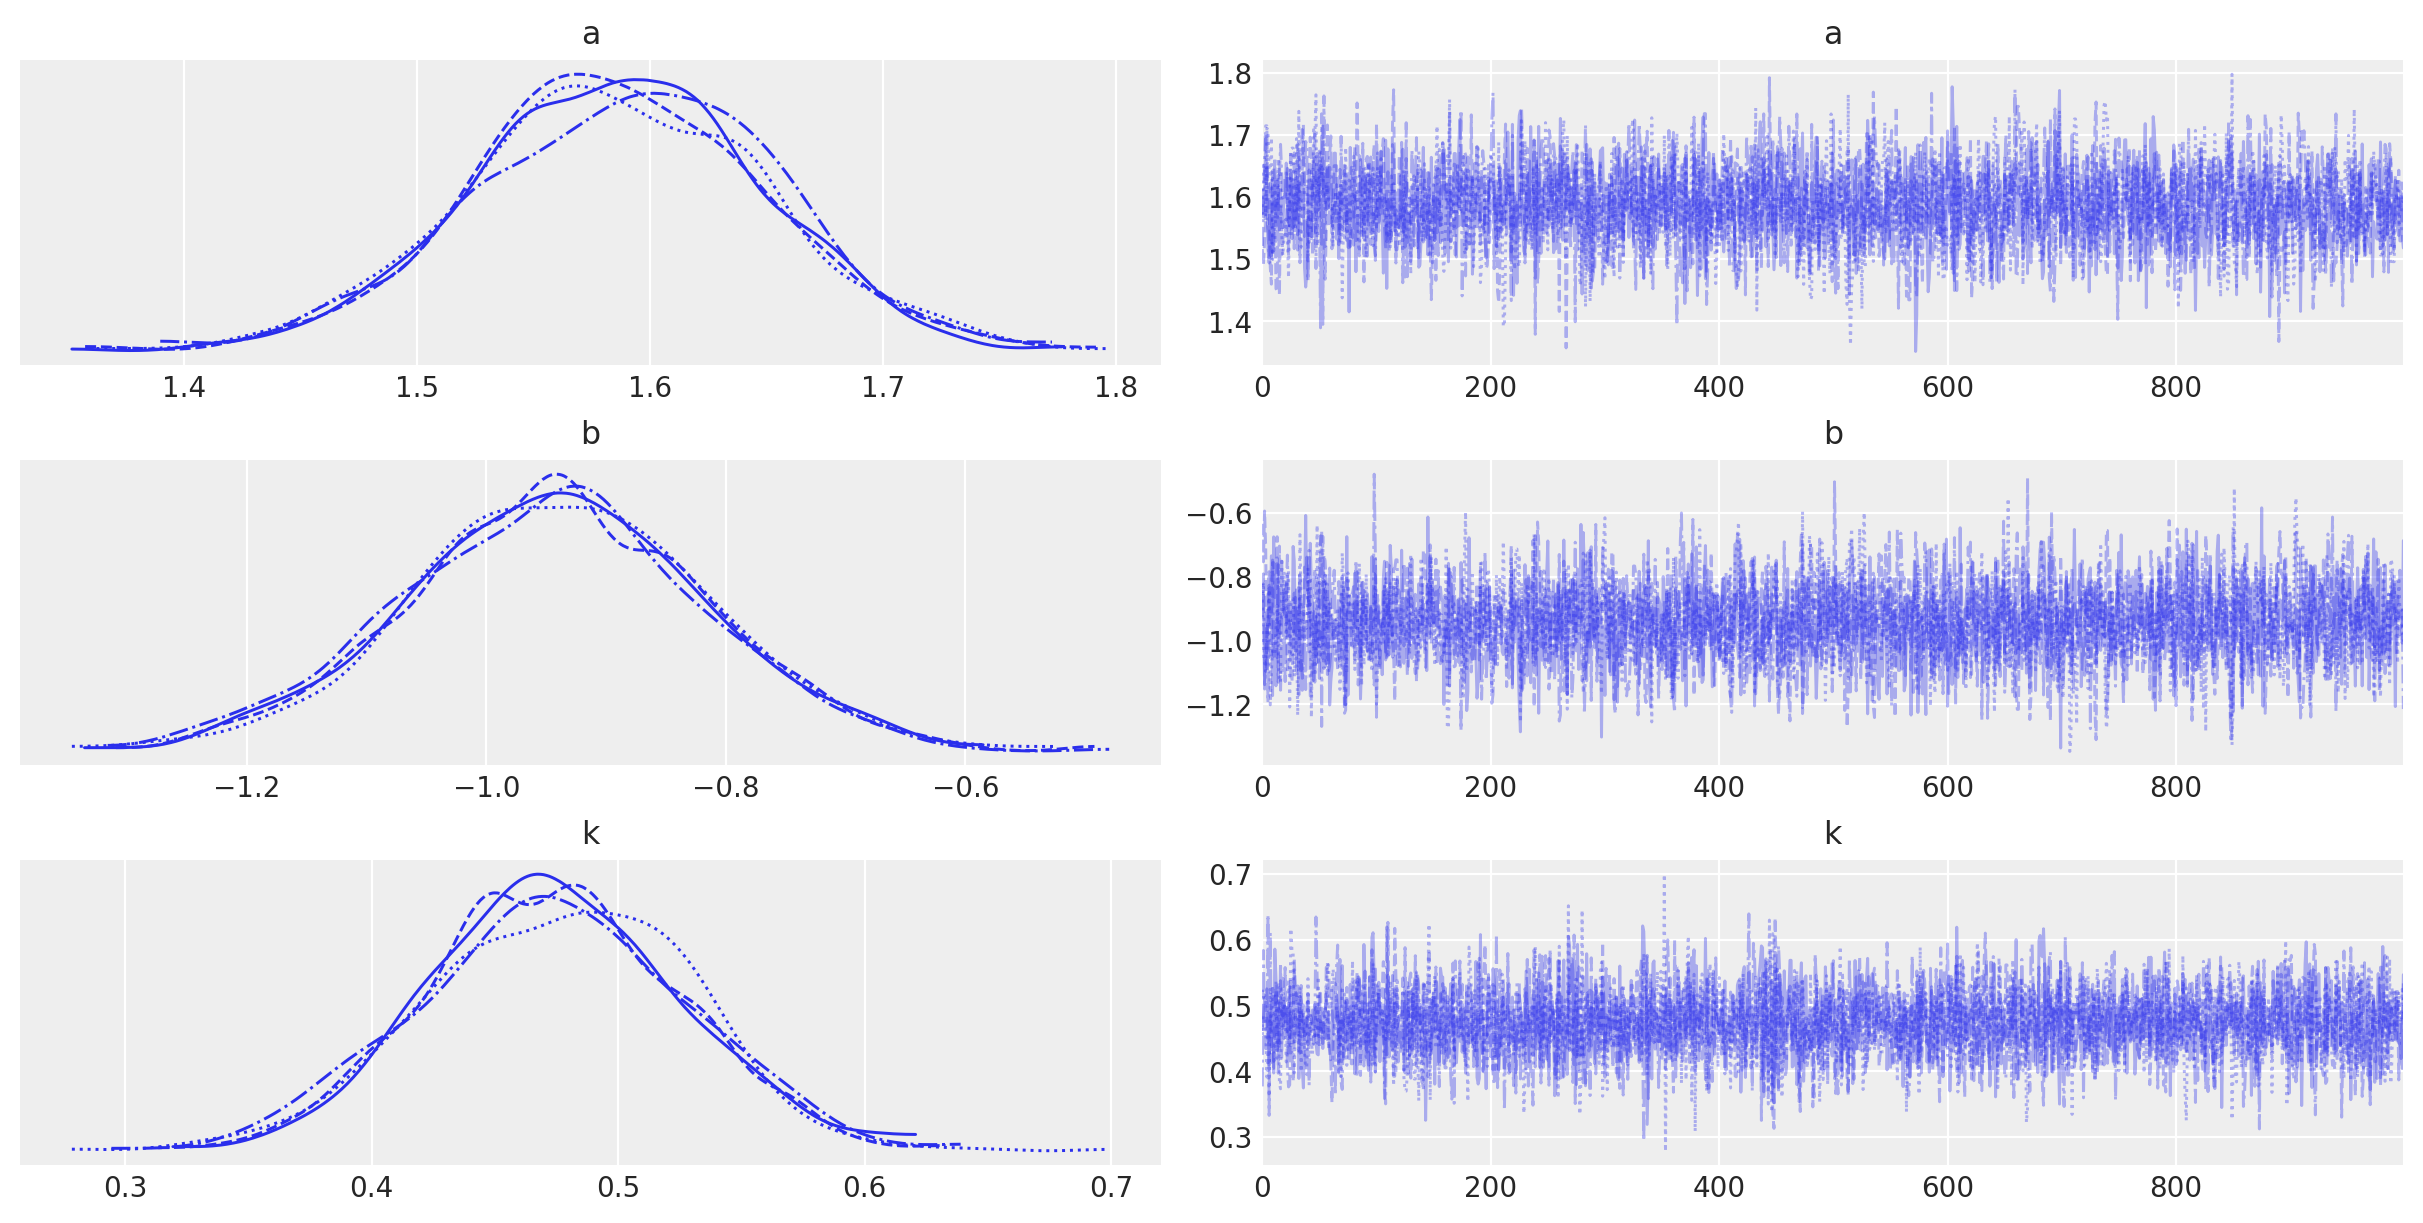

In [35]:
az.plot_trace(idata_m15_8, var_names=["a", "b", "k"]);

#### Code 15.31

In [37]:
# with pm.Model() as m15_9:
#     # priors
#     a = pm.Normal("a", 0, 1)
#     b = pm.Normal("b", 0, 0.5)
#     k = pm.Beta("k", 2, 2)

#     # cat NA
#     custom_logp = pm.math.logsumexp(
#         pm.math.log(k)
#         + pm.Poisson.dist(pm.math.exp(a + b)).logp(notes[cat == -9])
#         + pm.math.log(1 - k)
#         + pm.Poisson.dist(pm.math.exp(a)).logp(notes[cat == -9])
#     )
#     notes_RC_1 = pm.Potential("notes|RC==1", custom_logp)

#     # cat known present/absent
#     cat_RC_0 = pm.Bernoulli("cat|RC==0", k, observed=cat[cat != -9])
#     lam = pm.math.exp(a + b * cat_RC_0)
#     notes_RC_0 = pm.Poisson("notes|RC==0", lam, observed=notes[cat != -9])

#     # imputed values
#     lpC0 = pm.Deterministic(
#         "lpC0", pm.math.log(1 - k) + pm.Poisson.dist(pm.math.exp(a)).logp(notes)
#     )
#     lpC1 = pm.Deterministic(
#         "lpC1", pm.math.log(k) + pm.Poisson.dist(pm.math.exp(a + b)).logp(notes)
#     )
#     PrC1 = pm.Deterministic("PrC1", pm.math.exp(lpC1) / (pm.math.exp(lpC1) + pm.math.exp(lpC0)))

#     idata_m15_9 = pm.sample(return_inferencedata=True, random_seed=RANDOM_SEED)
# az.summary(idata_m15_9, var_names=["a", "b", "k"], round_to=2)

with pm.Model() as m15_9:
    # Priors
    a = pm.Normal("a", 0, 1)
    b = pm.Normal("b", 0, 0.5)
    k = pm.Beta("k", 2, 2)

    # Masks
    idx_known = cat != -9
    idx_unknown = cat == -9

    # Notes subset
    notes_known = notes[idx_known]
    notes_unknown = notes[idx_unknown]

    # Likelihood for known categories
    cat_RC_0 = pm.Bernoulli("cat_RC_0", k, observed=cat[idx_known])
    lam = pm.math.exp(a + b * cat_RC_0)
    notes_RC_0 = pm.Poisson("notes_RC_0", lam, observed=notes_known)

    # Custom log-likelihood for unknown categories using Poisson mixture
    mu1 = pm.math.exp(a + b)
    mu0 = pm.math.exp(a)

    logp1 = pm.logp(pm.Poisson.dist(mu=mu1), notes_unknown)
    logp0 = pm.logp(pm.Poisson.dist(mu=mu0), notes_unknown)

    custom_logp = pm.math.logaddexp(pm.math.log(k) + logp1,
                                    pm.math.log(1 - k) + logp0)

    pm.Potential("notes_RC_1", custom_logp)

    # Imputed probabilities for ALL notes (for diagnostic plots)
    lpC1 = pm.Deterministic("lpC1", pm.math.log(k) + pm.logp(pm.Poisson.dist(mu=mu1), notes))
    lpC0 = pm.Deterministic("lpC0", pm.math.log(1 - k) + pm.logp(pm.Poisson.dist(mu=mu0), notes))
    PrC1 = pm.Deterministic("PrC1", pm.math.exp(lpC1) / (pm.math.exp(lpC1) + pm.math.exp(lpC0)))

    # Sampling
    idata_m15_9 = pm.sample(return_inferencedata=True, random_seed=RANDOM_SEED)

# Summary of key parameters
az.summary(idata_m15_9, var_names=["a", "b", "k"], round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, k]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.59,0.06,1.49,1.69,0.0,0.0,3251.06,2766.74,1.0
b,-0.94,0.12,-1.13,-0.73,0.0,0.0,3265.75,2640.27,1.0
k,0.47,0.05,0.39,0.55,0.0,0.0,4466.33,3012.25,1.0


In [38]:
# Posterior P(C==1|N)
PrC1_hdi = az.hdi(idata_m15_9.posterior["PrC1"])["PrC1"]

# For display purposes, sort by whether the cat was absent or present
sorted_cats = np.argsort(cat_true)
cat_true_sorted = cat_true[sorted_cats]
PrC1_hdi_sorted = PrC1_hdi[sorted_cats]
cat_obs_sorted = cat[sorted_cats]

# We will give a different colour to cases where we don't know if the cat is there
cat_obs_sorted[cat_obs_sorted == -9] = 2

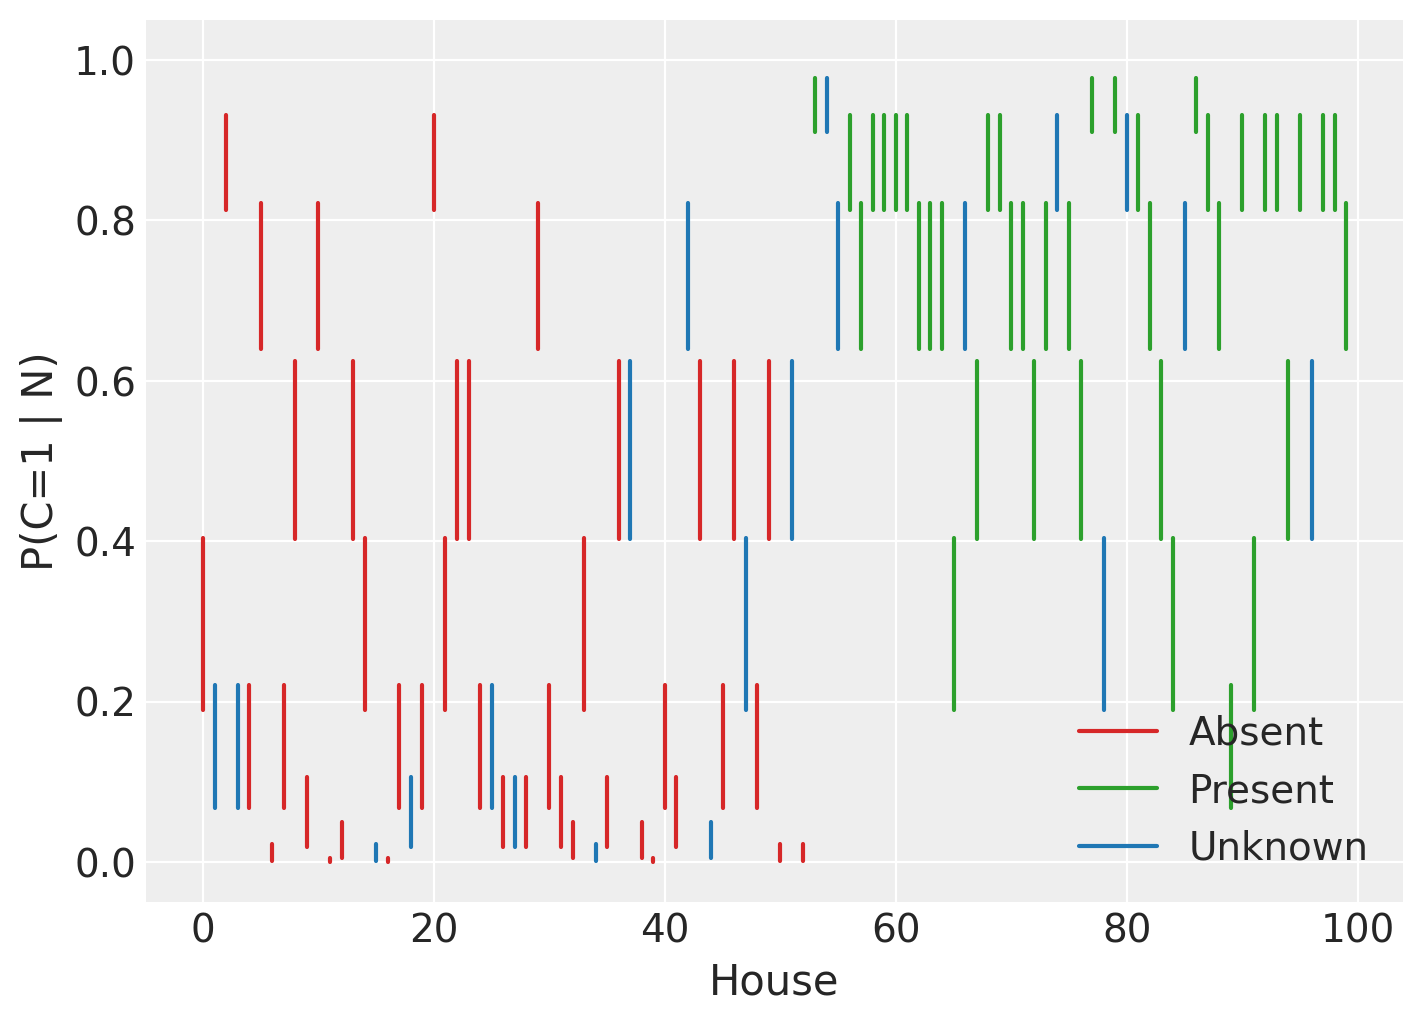

In [39]:
# Plot P(C==1 | N) for each house

labels = ["Absent", "Present", "Unknown"]
colours = ["tab:red", "tab:green", "tab:blue"]

fig, ax = plt.subplots(figsize=(7, 5))
for i in range(3):
    idx = cat_obs_sorted == i
    ax.plot(
        [np.flatnonzero(idx), np.flatnonzero(idx)],
        [PrC1_hdi_sorted[idx, 0], PrC1_hdi_sorted[idx, 1]],
        color=colours[i],
    )
    # Trick to have one label per group
    ax.axhline(2, color=colours[i], alpha=1, label=labels[i])

ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("House")
ax.set_ylabel("P(C=1 | N)")
ax.legend();

15M2.  Reconsider the primate milk missing data example from the chapter. This time, assign B a distribution that is properly bounded between zero and 1. A beta distribution, for example, is a good choice.

In [44]:
eps = 1e-3
B_transformed = np.clip(B, eps, 1 - eps)

with pm.Model() as m15_5_v2:
    sigma = pm.Exponential("sigma", 1)
    bM = pm.Normal("bM", 0, 0.5)
    bB = pm.Normal("bB", 0, 0.5)
    a = pm.Normal("a", 0, 0.5)
    # Parameters for Beta distribution (must be positive)
    alpha_B = pm.Exponential("alpha_B", 1)
    beta_B = pm.Exponential("beta_B", 1)
    # PyMC automatically imputes missing values
    # Bi = pm.Normal("Bi", nu, sigma_B, observed=B)
    Bi = pm.Beta("Bi", alpha=alpha_B, beta=beta_B, observed=B_transformed)

    mu = a + bB * Bi + bM * M

    Ki = pm.Normal("Ki", mu, sigma, observed=K)

    idata_m15_5_v2 = pm.sample(return_inferencedata=True, random_seed=RANDOM_SEED)
az.summary(idata_m15_5_v2, round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, bM, bB, a, alpha_B, beta_B, Bi_unobserved]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
There were 12 divergences after tuning. Increase `target_accept` or reparameterize.
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/mnt/c/Users/risto/projects/pymc-resources/.venv/li

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bM,-0.36,0.19,-0.66,-0.07,0.00,0.00,4101.16,3277.08,1.0
bB,0.33,0.40,-0.30,0.99,0.01,0.01,2937.72,2836.21,1.0
a,-0.10,0.21,-0.41,0.27,0.00,0.00,2978.68,2676.12,1.0
sigma,0.96,0.14,0.72,1.16,0.00,0.00,3599.71,2755.16,1.0
alpha_B,0.22,0.06,0.12,0.31,0.00,0.00,1691.60,2873.79,1.0
beta_B,0.38,0.12,0.20,0.56,0.00,0.00,1959.95,2719.67,1.0
Bi_unobserved[0],0.33,0.37,0.00,0.96,0.01,0.00,3772.41,1798.44,1.0
Bi_unobserved[1],0.30,0.37,0.00,0.96,0.01,0.00,3012.07,1411.01,1.0
Bi_unobserved[2],0.32,0.37,0.00,0.96,0.01,0.00,3050.48,1511.67,1.0
Bi_unobserved[3],0.34,0.38,0.00,0.96,0.01,0.00,3306.72,1834.89,1.0


In [45]:
az.summary(idata_m15_5, round_to=2)

/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnost

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bM,-0.53,0.21,-0.88,-0.22,0.00,0.00,2912.76,3191.44,1.0
bB,0.48,0.24,0.10,0.87,0.01,0.00,2136.29,2693.08,1.0
nu,-0.05,0.21,-0.40,0.28,0.00,0.00,3611.19,2891.25,1.0
a,0.03,0.17,-0.22,0.31,0.00,0.00,6110.82,3221.31,1.0
Bi_unobserved[0],-0.57,0.93,-2.00,0.92,0.01,0.02,4405.98,2841.04,1.0
Bi_unobserved[1],-0.68,0.97,-2.24,0.82,0.02,0.02,4132.35,2394.38,1.0
Bi_unobserved[2],-0.67,0.95,-2.18,0.76,0.01,0.02,4474.57,3248.53,1.0
Bi_unobserved[3],-0.28,0.90,-1.67,1.19,0.01,0.02,6754.87,3156.22,1.0
Bi_unobserved[4],0.43,0.92,-0.93,1.95,0.01,0.02,5073.04,3201.34,1.0
Bi_unobserved[5],-0.17,0.91,-1.52,1.35,0.01,0.01,5882.33,3024.60,1.0


15M3.  Repeat the divorce data measurement error models, but this time double the standard errors. Can you explain how doubling the standard errors impacts inference?

In [51]:
d = pd.read_csv("Data/WaffleDivorce.csv", sep=";")
D_obs = standardize(d["Divorce"])
D_sd = d["Divorce SE"] / d["Divorce"].std()
M = standardize(d["Marriage"])
A = standardize(d["MedianAgeMarriage"])
N = len(d)

In [52]:
with pm.Model() as m15_1_v2:
    sigma = pm.Exponential("sigma", 1)
    bM = pm.Normal("bM", 0, 0.5)
    bA = pm.Normal("bA", 0, 0.5)
    a = pm.Normal("a", 0, 0.2)

    mu = a + bA * A + bM * M  # linear model to assess A -> D
    D_true = pm.Normal("D_true", mu, sigma, shape=N)  # distribution for true values

    D = pm.Normal("D_obs", D_true, D_sd*2, observed=D_obs)  # distribution for observed values

    idata_m15_1_v2 = pm.sample(return_inferencedata=True, random_seed=RANDOM_SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, bM, bA, a, D_true]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
There were 507 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [53]:
az.summary(idata_m15_1_v2)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bM,0.218,0.184,-0.038,0.538,0.016,0.006,131.0,299.0,1.03
bA,-0.627,0.166,-0.885,-0.369,0.013,0.005,158.0,675.0,1.03
a,-0.106,0.105,-0.268,0.053,0.008,0.004,171.0,430.0,1.02
D_true[0],0.367,0.264,-0.058,0.754,0.018,0.009,268.0,886.0,1.02
D_true[1],0.678,0.356,0.106,1.232,0.018,0.013,367.0,1097.0,1.02
D_true[2],0.084,0.245,-0.284,0.470,0.008,0.014,714.0,1062.0,1.02
D_true[3],1.175,0.351,0.639,1.766,0.018,0.011,364.0,1005.0,1.01
D_true[4],-0.693,0.183,-0.994,-0.417,0.009,0.005,461.0,1337.0,1.02
D_true[5],0.304,0.290,-0.194,0.723,0.011,0.010,605.0,1467.0,1.04
D_true[6],-1.096,0.251,-1.502,-0.698,0.009,0.009,749.0,1306.0,1.02


In [57]:
D_obs = standardize(d["Divorce"])
D_sd = d["Divorce SE"] / d["Divorce"].std()
M_obs = standardize(d["Marriage"])
M_sd = d["Marriage SE"] / d["Marriage"].std()
A = standardize(d["MedianAgeMarriage"])
N = len(d)

In [66]:
with pm.Model() as m15_2_v2:
    sigma = pm.Exponential("sigma", 1)
    bM = pm.Normal("bM", 0, 0.5)
    bA = pm.Normal("bA", 0, 0.5)
    a = pm.Normal("a", 0, 0.2)

    M_true = pm.Normal("M_true", 0, 1, shape=N)  # distribution for true M values
    mu = a + bA * A + bM * M_true  # linear model
    D_true = pm.Normal("D_true", mu, sigma, shape=N)  # distribution for true D values

    D = pm.Normal("D_obs", D_true, D_sd*2, observed=D_obs)  # distribution for observed D values
    M = pm.Normal("M_obs", M_true, M_sd*2, observed=M_obs)  # distribution for observed M values

    idata_m15_2_v2 = pm.sample(return_inferencedata=True, random_seed=RANDOM_SEED)

az.summary(idata_m15_2_v2, var_names=["~D_true", "~M_true"], round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, bM, bA, a, M_true, D_true]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
There were 402 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bM,0.34,0.20,0.03,0.64,0.02,0.00,124.96,654.79,1.04
bA,-0.60,0.15,-0.83,-0.36,0.01,0.00,246.08,820.76,1.02
a,-0.07,0.11,-0.27,0.11,0.01,0.01,101.42,49.35,1.05
sigma,0.17,0.09,0.05,0.29,0.01,0.00,42.95,100.84,1.08


In [68]:
az.summary(idata_m15_2, var_names=["~D_true", "~M_true"], round_to=2)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bM,0.20,0.21,-0.14,0.53,0.0,0.0,2318.87,2612.11,1.0
bA,-0.55,0.16,-0.79,-0.28,0.0,0.0,3337.59,3573.89,1.0
a,-0.04,0.10,-0.20,0.11,0.0,0.0,4910.79,2967.39,1.0
sigma,0.56,0.11,0.38,0.73,0.0,0.0,1239.25,911.72,1.0


In [64]:
az.summary(idata_m15_1_v2, var_names=["~D_true", "~M_true"], round_to=2)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bM,0.22,0.18,-0.04,0.54,0.02,0.01,131.33,299.14,1.03
bA,-0.63,0.17,-0.89,-0.37,0.01,0.01,157.66,674.54,1.03
a,-0.11,0.10,-0.27,0.05,0.01,0.00,170.96,429.99,1.02
sigma,0.22,0.10,0.09,0.35,0.02,0.00,14.51,138.04,1.20


In [65]:
az.summary(idata_m15_1, var_names=["~D_true", "~M_true"], round_to=2)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bM,0.05,0.17,-0.22,0.31,0.0,0.0,2675.50,2824.99,1.0
bA,-0.61,0.16,-0.85,-0.34,0.0,0.0,2893.51,2849.09,1.0
a,-0.05,0.10,-0.20,0.10,0.0,0.0,3166.65,2652.57,1.0
sigma,0.59,0.11,0.42,0.76,0.0,0.0,1415.52,1500.87,1.0


Doubling the standard errors in the measurement error model allows the model to account for more noise in the observed variables. This reduces residual variance (sigma) and strengthens the estimated relationship between predictors and response (e.g., higher bM). It shows that modeling measurement error explicitly, especially with more uncertainty, can help uncover truer underlying effects by shifting noise away from the signal.

15M4.  Simulate data from this DAG: X → Y → Z. Now fit a model that predicts Y using both X and Z. What kind of confound arises, in terms of inferring the causal influence of X on Y

In [71]:
X =np.random.randn(100)
Y = X*0.7+ np.random.randn(100)
Z = Y *0.8+np.random.randn(100)

Y=standardize(Y)
Z = standardize(Z)

In [78]:
with pm.Model() as m_pipe:
    sigma = pm.Exponential("sigma", 1)
    bX = pm.Normal("bX", 0, 1.0)
    bZ = pm.Normal("bZ", 0, 1.0)
    a = pm.Normal("a", 0, 1.0)

    mu = a + bX * X + bZ * Z  

    Y = pm.Normal("Y", mu, sigma, observed=Y)  # distribution for observed values

    idata_m_pipe = pm.sample(return_inferencedata=True, random_seed=RANDOM_SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, bX, bZ, a]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [79]:
az.summary(idata_m_pipe)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bX,0.468,0.073,0.349,0.583,0.001,0.001,3643.0,2839.0,1.0
bZ,0.453,0.071,0.344,0.572,0.001,0.001,3832.0,3500.0,1.0
a,0.023,0.066,-0.081,0.126,0.001,0.001,4930.0,3108.0,1.0
sigma,0.652,0.048,0.575,0.724,0.001,0.001,5856.0,3395.0,1.0


By conditioning on Z (which lies downstream of Y in the causal path X → Y → Z), we introduce post-treatment bias. This causes the model to misattribute some of the causal effect of X on Y to Z, because Z reflects variation in Y. The result is a distorted estimate of the causal influence of X — often attenuated, due to multicollinearity between X and Z.

15M5.  Return to the singing bird model, m15.9, and compare the posterior estimates of cat presence (PrC1) to the true simulated values. How good is the model at inferring the missing data? Can you think of a way to change the simulation so that the precision of the inference is stronger?

In [81]:
N_houses = 100  # Number of houses to simulate
alpha = 5  # Average number of notes when cat is absent
beta = -3  # Difference in number of notes when cat is present
k_true = 0.5  # Probability of cat present
r = 0.2  # Probability of not knowing whether cat present/absent

cat_true = rng.binomial(n=1, p=k_true, size=N_houses)
notes = rng.poisson(lam=alpha + beta * cat_true, size=N_houses)
R_C = rng.binomial(n=1, p=r, size=N_houses)
cat = cat_true.copy()
cat[R_C == 1] = -9

In [82]:
with pm.Model() as m15_9:
    # Priors
    a = pm.Normal("a", 0, 1)
    b = pm.Normal("b", 0, 0.5)
    k = pm.Beta("k", 2, 2)

    # Masks
    idx_known = cat != -9
    idx_unknown = cat == -9

    # Notes subset
    notes_known = notes[idx_known]
    notes_unknown = notes[idx_unknown]

    # Likelihood for known categories
    cat_RC_0 = pm.Bernoulli("cat_RC_0", k, observed=cat[idx_known])
    lam = pm.math.exp(a + b * cat_RC_0)
    notes_RC_0 = pm.Poisson("notes_RC_0", lam, observed=notes_known)

    # Custom log-likelihood for unknown categories using Poisson mixture
    mu1 = pm.math.exp(a + b)
    mu0 = pm.math.exp(a)

    logp1 = pm.logp(pm.Poisson.dist(mu=mu1), notes_unknown)
    logp0 = pm.logp(pm.Poisson.dist(mu=mu0), notes_unknown)

    custom_logp = pm.math.logaddexp(pm.math.log(k) + logp1,
                                    pm.math.log(1 - k) + logp0)

    pm.Potential("notes_RC_1", custom_logp)

    # Imputed probabilities for ALL notes (for diagnostic plots)
    lpC1 = pm.Deterministic("lpC1", pm.math.log(k) + pm.logp(pm.Poisson.dist(mu=mu1), notes))
    lpC0 = pm.Deterministic("lpC0", pm.math.log(1 - k) + pm.logp(pm.Poisson.dist(mu=mu0), notes))
    PrC1 = pm.Deterministic("PrC1", pm.math.exp(lpC1) / (pm.math.exp(lpC1) + pm.math.exp(lpC0)))

    # Sampling
    idata_m15_9 = pm.sample(return_inferencedata=True, random_seed=RANDOM_SEED)

# Summary of key parameters
az.summary(idata_m15_9, var_names=["a", "b", "k"], round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, k]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.53,0.07,1.43,1.63,0.0,0.0,3513.70,2778.34,1.0
b,-1.04,0.13,-1.26,-0.84,0.0,0.0,3242.92,3000.40,1.0
k,0.49,0.05,0.41,0.57,0.0,0.0,3941.52,2680.88,1.0


In [87]:
df_m15_9=az.summary(idata_m15_9, var_names=["PrC1"], round_to=2)
df_m15_9

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
PrC1[0],0.04,0.02,0.01,0.07,0.0,0.0,3816.27,3068.15,1.0
PrC1[1],0.70,0.06,0.61,0.79,0.0,0.0,3980.91,3121.95,1.0
PrC1[2],0.00,0.00,0.00,0.01,0.0,0.0,3531.42,3243.13,1.0
PrC1[3],0.10,0.04,0.04,0.16,0.0,0.0,4017.79,3303.42,1.0
PrC1[4],0.95,0.02,0.92,0.98,0.0,0.0,3234.76,2606.80,1.0
...,...,...,...,...,...,...,...,...,...
PrC1[95],0.87,0.04,0.81,0.93,0.0,0.0,3471.79,3081.90,1.0
PrC1[96],0.70,0.06,0.61,0.79,0.0,0.0,3980.91,3121.95,1.0
PrC1[97],0.10,0.04,0.04,0.16,0.0,0.0,4017.79,3303.42,1.0
PrC1[98],0.02,0.01,0.00,0.03,0.0,0.0,3685.20,3241.40,1.0


In [88]:
df_m15_9['real']=cat

In [95]:
df_m15_9[['mean','real']].groupby('real')['mean'].median()

real
-9    0.460
 0    0.100
 1    0.785
Name: mean, dtype: float64

In [101]:
# df_m15_9[['mean','real']].sample(30)

0       Axes(0.125,0.11;0.352273x0.77)
1    Axes(0.547727,0.11;0.352273x0.77)
dtype: object

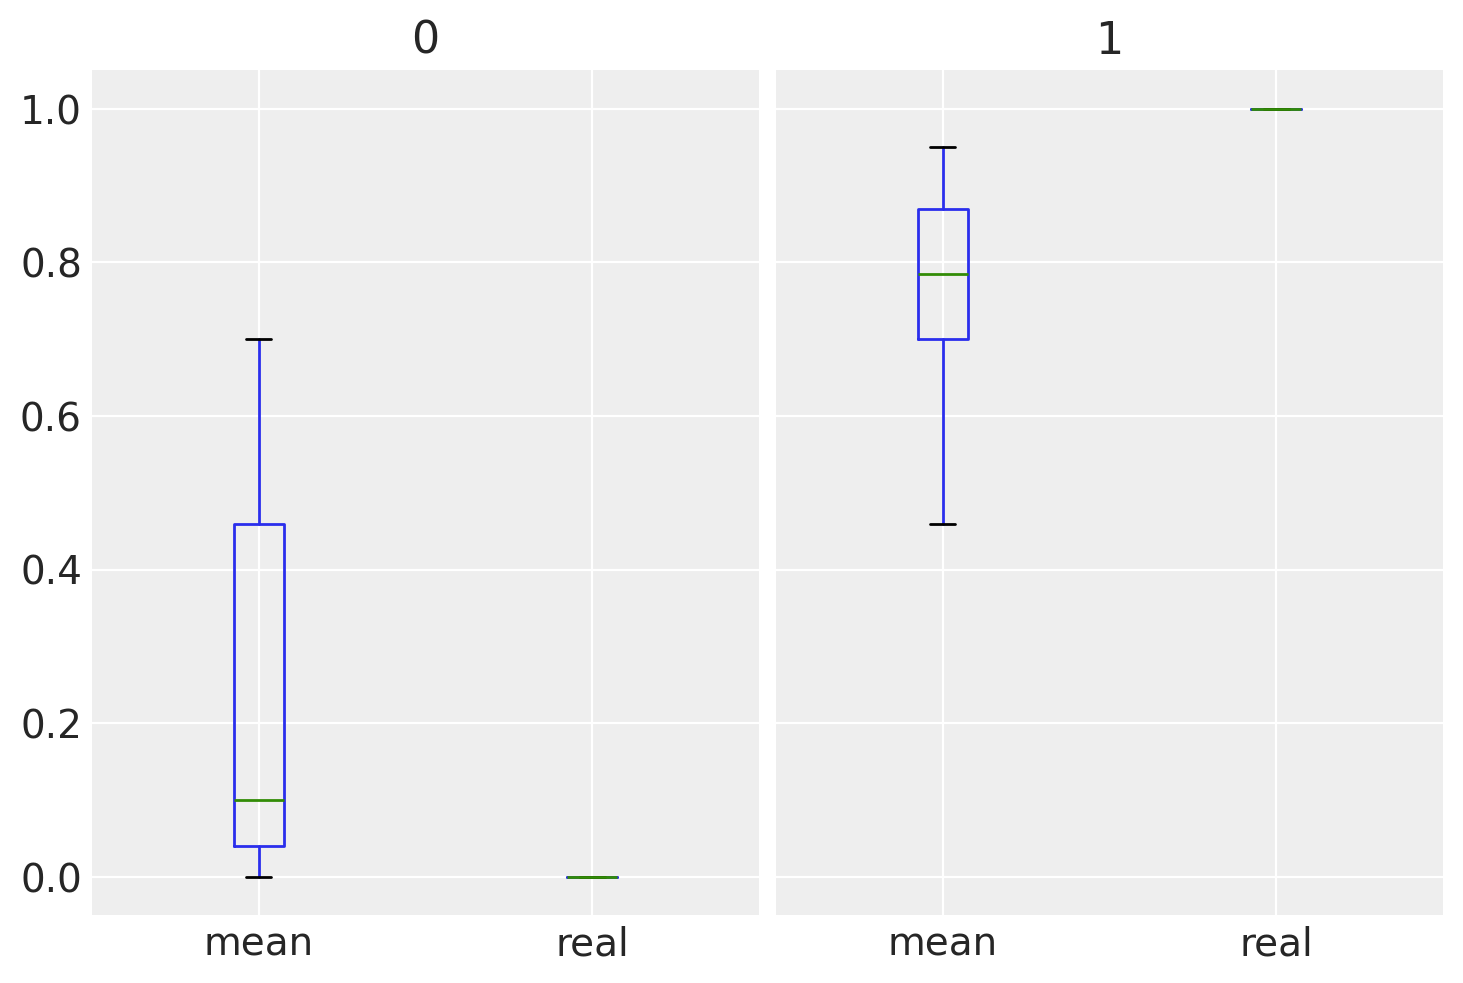

In [96]:
df_m15_9[df_m15_9.real!=-9][['mean','real']].groupby('real').boxplot()

-9    Axes(0.125,0.11;0.775x0.77)
dtype: object

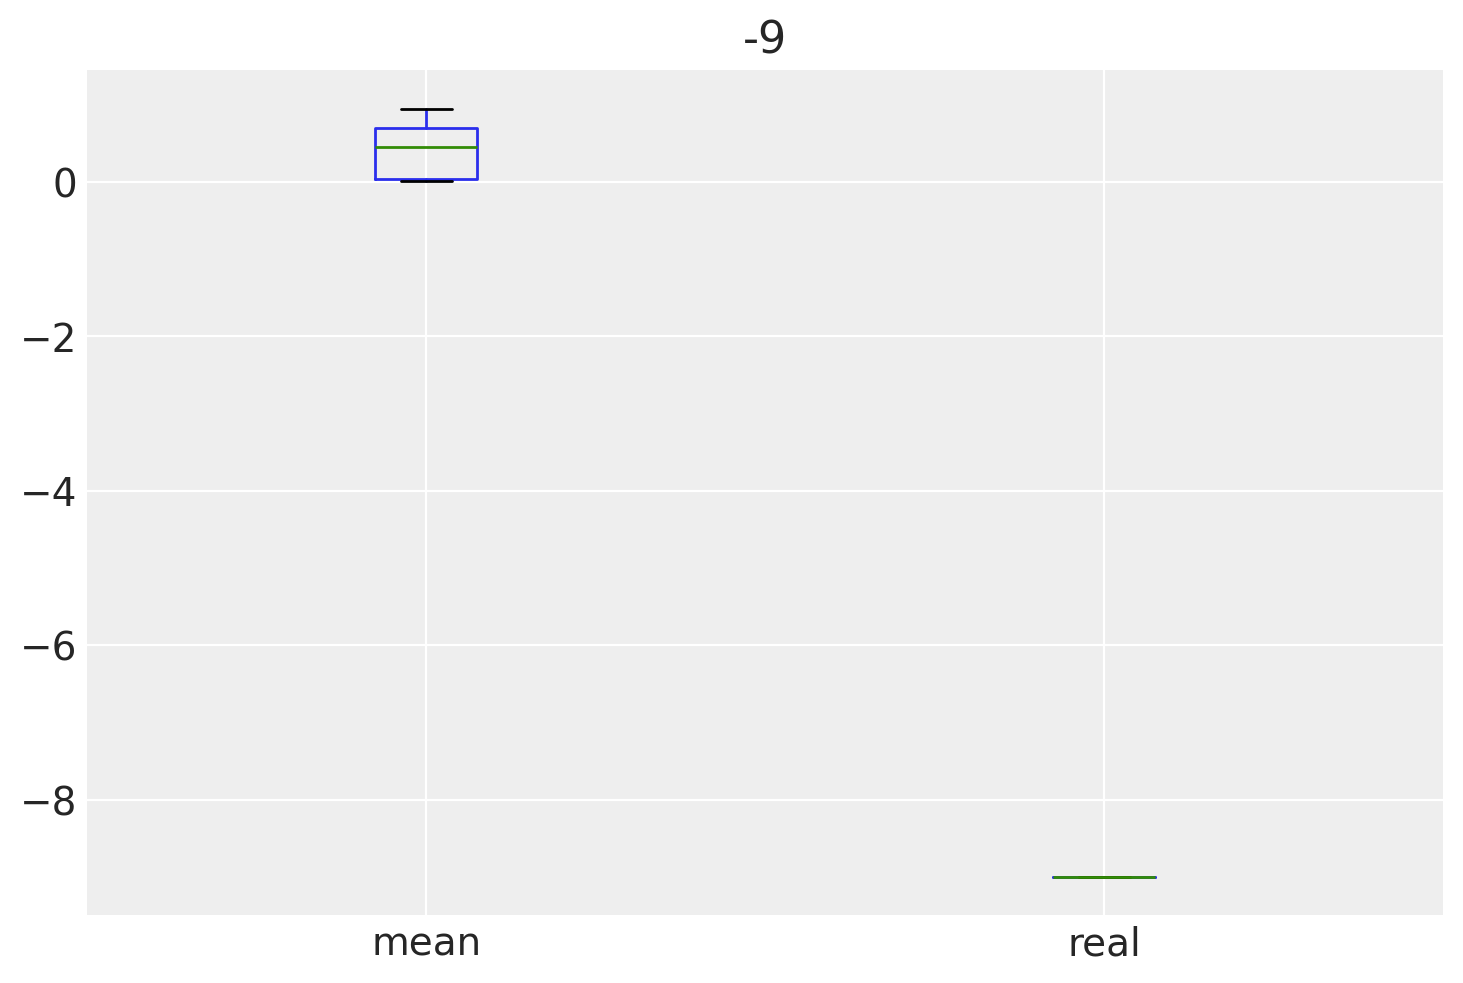

In [97]:
df_m15_9[df_m15_9.real==-9][['mean','real']].groupby('real').boxplot()

The model does a decent job inferring missing PrC1 values, but uncertainty remains high because the model lacks sufficient information to distinguish 0 from 1 in those cases. To improve precision, you can simulate or include additional predictors that influence cat presence. This gives the model more clues to infer the true values, reducing posterior uncertainty. You can also simulate stronger signal-to-noise ratios or increase sample size to aid inference.

15M6.  Return to the four dog-eats-homework missing data examples. Simulate each and then fit one or more models to try to recover valid estimates for S → H.

#### random

In [115]:
N = 1000  # Number of students
X = rng.normal(size=N)  # Unobserved noise
S = rng.normal(size=N)  # Study effort (observed)

# Homework grade affected only by study effort
H = rng.binomial(n=10, p=invlogit(2 + S), size=N)

# MCAR: Random missingness, independent of all variables
D = rng.random(size=N) < 0.3  # 30% missing completely at random
H_obs = H.copy()
H_obs = H.astype(float)
H_obs[D] = np.nan

In [117]:
with pm.Model() as m_mcar:
    a = pm.Normal("a", 0, 1)
    bS = pm.Normal("bS", 0, 0.5)
    
    p = pm.math.sigmoid(a + bS * S)
    
    H_est = pm.Binomial("H", n=10, p=p, observed=H_obs)

    idata_mcar = pm.sample(return_inferencedata=True, random_seed=123)

az.summary(idata_mcar, round_to=2)

/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/pymc/model/core.py:1295: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [a, bS]
>Metropolis: [H_unobserved]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 20 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.p

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,2.02,0.04,1.96,2.08,0.00,0.00,1015.51,1877.38,1.01
bS,0.97,0.04,0.91,1.04,0.00,0.00,858.13,1334.01,1.01
H_unobserved[0],7.70,1.36,5.00,9.00,0.05,0.04,844.32,871.81,1.00
H_unobserved[1],7.97,1.24,5.00,9.00,0.04,0.03,789.05,945.14,1.01
H_unobserved[2],9.20,0.86,8.00,10.00,0.03,0.02,775.88,765.09,1.00
...,...,...,...,...,...,...,...,...,...
H[995],9.00,0.00,9.00,9.00,0.00,NaN,4000.00,4000.00,NaN
H[996],9.00,0.00,9.00,9.00,0.00,NaN,4000.00,4000.00,NaN
H[997],8.95,0.96,8.00,10.00,0.03,0.03,775.75,816.24,1.00
H[998],8.00,0.00,8.00,8.00,0.00,NaN,4000.00,4000.00,NaN


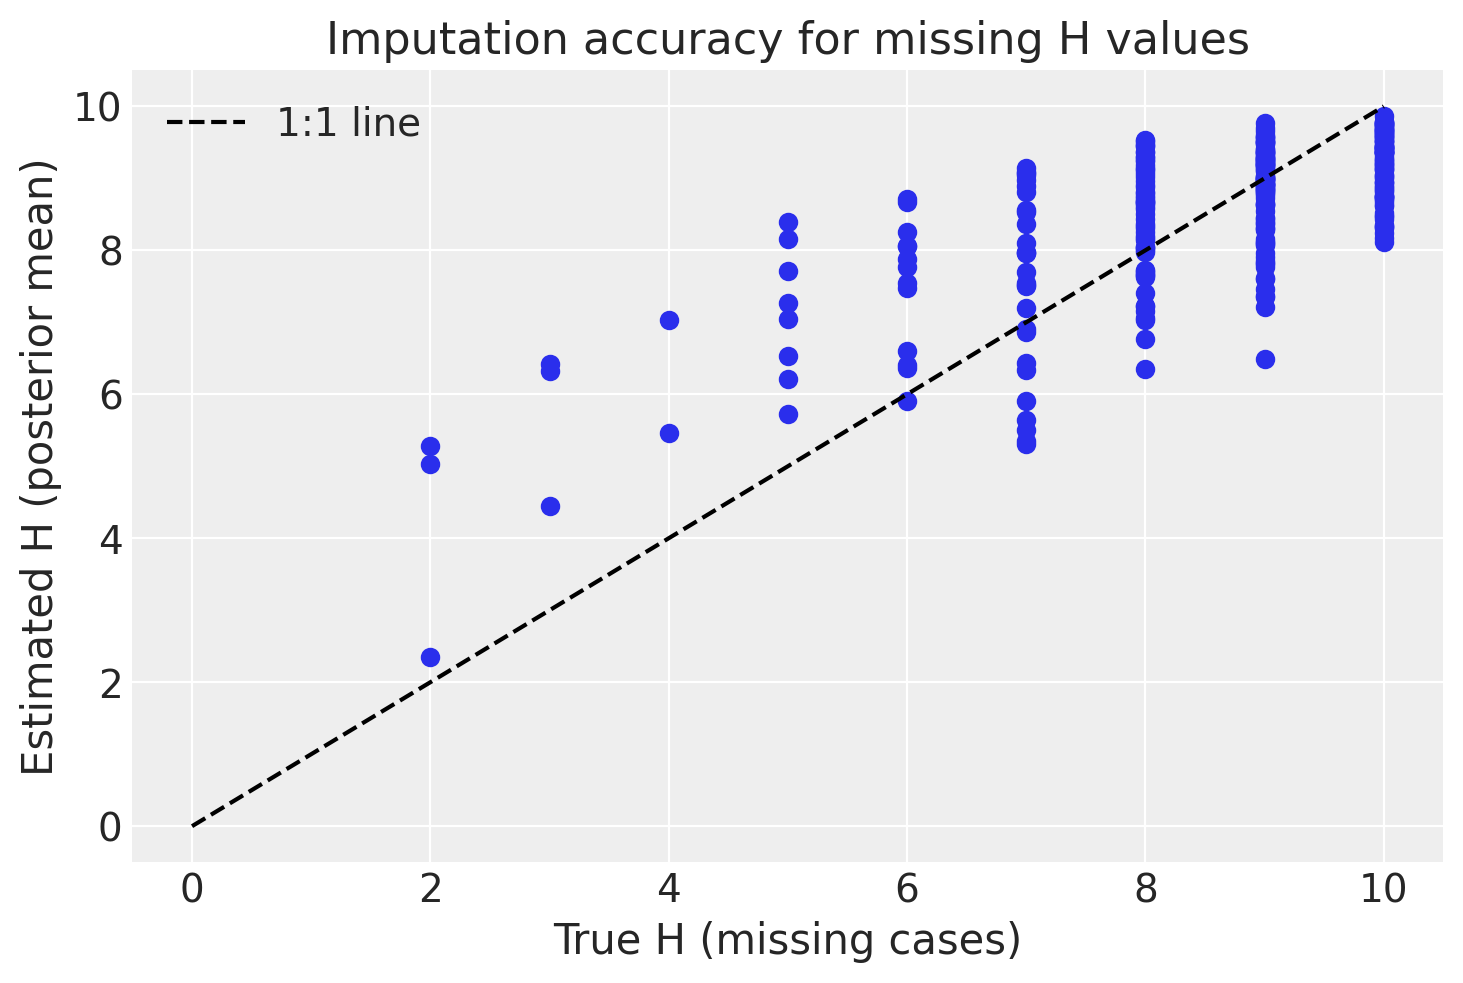

In [119]:
# Extract posterior samples for imputed H
H_missing_posterior = idata_mcar.posterior["H_unobserved"]  # shape: (chains, draws, n_missing)

# Compute posterior means
H_missing_mean = H_missing_posterior.mean(dim=("chain", "draw")).values
true_missing_H = H[D]

# Scatter plot: true vs estimated H for missing values
plt.scatter(true_missing_H, H_missing_mean)
plt.xlabel("True H (missing cases)")
plt.ylabel("Estimated H (posterior mean)")
plt.title("Imputation accuracy for missing H values")
plt.plot([0, 10], [0, 10], "k--", label="1:1 line")
plt.legend()
plt.show()

#### Depends on S

In [135]:
N = 1000  # Number of students
X = rng.normal(size=N)  # Unobserved noise
S = rng.normal(size=N)  # Study effort (observed)

# Homework grade affected only by study effort
H = rng.binomial(n=10, p=invlogit(2 + S), size=N)

# missinggness depends on study levels
p_miss = invlogit(S - 1.1)  # smooth transition around S = 1.5
D = rng.random(size=N) < p_miss
H_obs = H.copy()
H_obs = H_obs.astype(float)
H_obs[D] = np.nan

In [136]:
with pm.Model() as m_mar:
    a = pm.Normal("a", 0, 1)
    bS = pm.Normal("bS", 0, 0.5)
    
    p = pm.math.sigmoid(a + bS * S)
    
    H_est = pm.Binomial("H", n=10, p=p, observed=H_obs)

    idata_mmar = pm.sample(return_inferencedata=True, random_seed=123)

az.summary(idata_mmar, round_to=2)

/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/pymc/model/core.py:1295: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [a, bS]
>Metropolis: [H_unobserved]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 19 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.p

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,2.03,0.04,1.97,2.10,0.00,0.00,670.23,1347.92,1.00
bS,1.02,0.04,0.95,1.08,0.00,0.00,761.16,1683.05,1.00
H_unobserved[0],9.11,0.87,8.00,10.00,0.03,0.02,726.72,793.30,1.00
H_unobserved[1],9.53,0.66,9.00,10.00,0.03,0.02,690.40,804.86,1.00
H_unobserved[2],8.19,1.22,7.00,10.00,0.04,0.03,857.93,1086.64,1.01
...,...,...,...,...,...,...,...,...,...
H[995],7.00,0.00,7.00,7.00,0.00,NaN,4000.00,4000.00,NaN
H[996],8.00,0.00,8.00,8.00,0.00,NaN,4000.00,4000.00,NaN
H[997],8.00,0.00,8.00,8.00,0.00,NaN,4000.00,4000.00,NaN
H[998],5.00,0.00,5.00,5.00,0.00,NaN,4000.00,4000.00,NaN


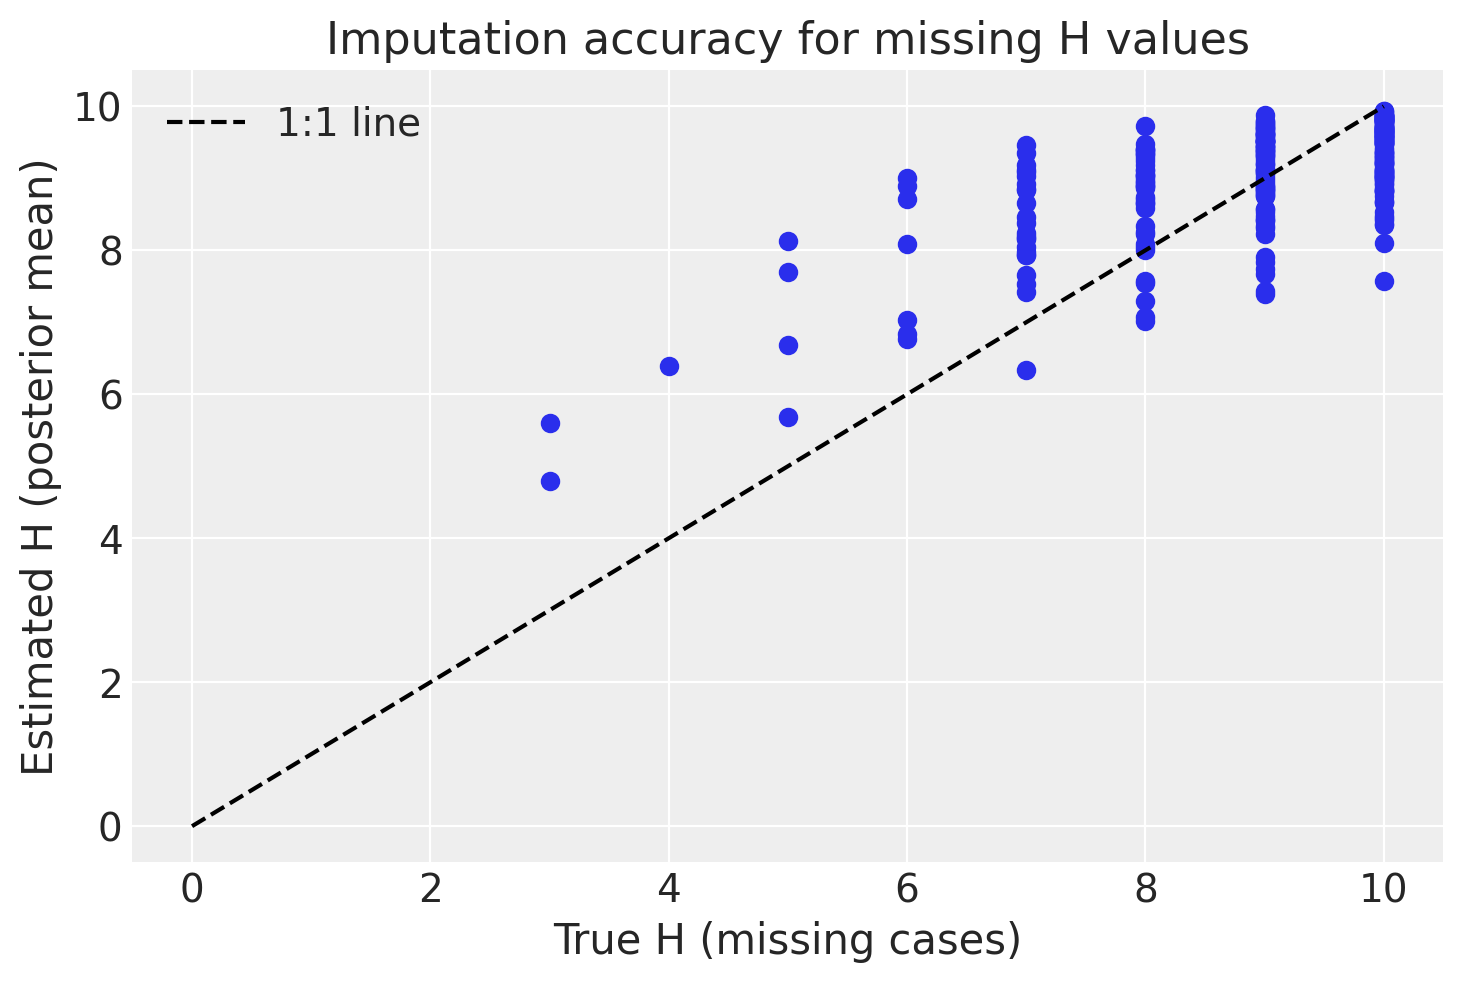

In [137]:
# Extract posterior samples for imputed H
H_missing_posterior = idata_mmar.posterior["H_unobserved"]  # shape: (chains, draws, n_missing)

# Compute posterior means
H_missing_mean = H_missing_posterior.mean(dim=("chain", "draw")).values
true_missing_H = H[D]

# Scatter plot: true vs estimated H for missing values
plt.scatter(true_missing_H, H_missing_mean)
plt.xlabel("True H (missing cases)")
plt.ylabel("Estimated H (posterior mean)")
plt.title("Imputation accuracy for missing H values")
plt.plot([0, 10], [0, 10], "k--", label="1:1 line")
plt.legend()
plt.show()

#### depends on x

In [138]:
N = 1000  # Number of students
X = rng.normal(size=N)  # Noise of house (unobserved)
S = rng.normal(size=N)  # How much each student studies
H = rng.binomial(
    n=10, p=invlogit(2 + S - 2 * X), size=N
)  # Homework grade affected by study and noise
D = X > 1  # Dogs eat homework in noisy houses

H_obs = H.astype(float)
H_obs[D] = np.nan

In [139]:
with pm.Model() as m_mnar_x:
    # Priors
    a = pm.Normal("a", 0, 1)
    bS = pm.Normal("bS", 0, 0.5)
    bX = pm.Normal("bX", -2, 0.5)  # We know true X → H effect is -2

    # Latent X (we don’t observe it)
    X_latent = pm.Normal("X", 0, 1, shape=N)

    # Linear model for p(H)
    p = pm.math.sigmoid(a + bS * S + bX * X_latent)

    # Homework completion (some values missing)
    H_like = pm.Binomial("H", n=10, p=p, observed=H_obs)

    # Model for missingness indicator
    d_alpha = pm.Normal("d_alpha", 0, 1)
    d_beta = pm.Normal("d_beta", 1, 0.5)
    logit_p_miss = d_alpha + d_beta * X_latent
    p_miss = pm.Deterministic("p_miss", pm.math.sigmoid(logit_p_miss))

    # Likelihood for observed missingness indicator D (True if H is missing)
    D_obs = pm.Bernoulli("D", p=p_miss, observed=D.astype(int))

    idata_mnar_x = pm.sample(random_seed=123, return_inferencedata=True)

/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/pymc/model/core.py:1295: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [a, bS, bX, X, d_alpha, d_beta]
>Metropolis: [H_unobserved]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [140]:
az.summary(idata_mnar_x)

/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnost

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,2.153,0.091,2.013,2.300,0.013,0.005,55.0,143.0,1.06
bS,1.062,0.065,0.969,1.176,0.003,0.001,646.0,1883.0,1.01
bX,-1.447,0.095,-1.608,-1.306,0.010,0.004,89.0,299.0,1.05
X[0],0.051,0.455,-0.639,0.827,0.007,0.008,4026.0,2511.0,1.00
X[1],0.144,0.511,-0.653,0.956,0.008,0.010,4177.0,2463.0,1.00
...,...,...,...,...,...,...,...,...,...
p_miss[995],0.205,0.092,0.057,0.341,0.001,0.003,3724.0,1615.0,1.01
p_miss[996],0.070,0.058,0.001,0.147,0.004,0.001,174.0,858.0,1.02
p_miss[997],0.102,0.088,0.000,0.208,0.003,0.002,393.0,748.0,1.01
p_miss[998],0.077,0.064,0.000,0.160,0.004,0.001,212.0,573.0,1.02


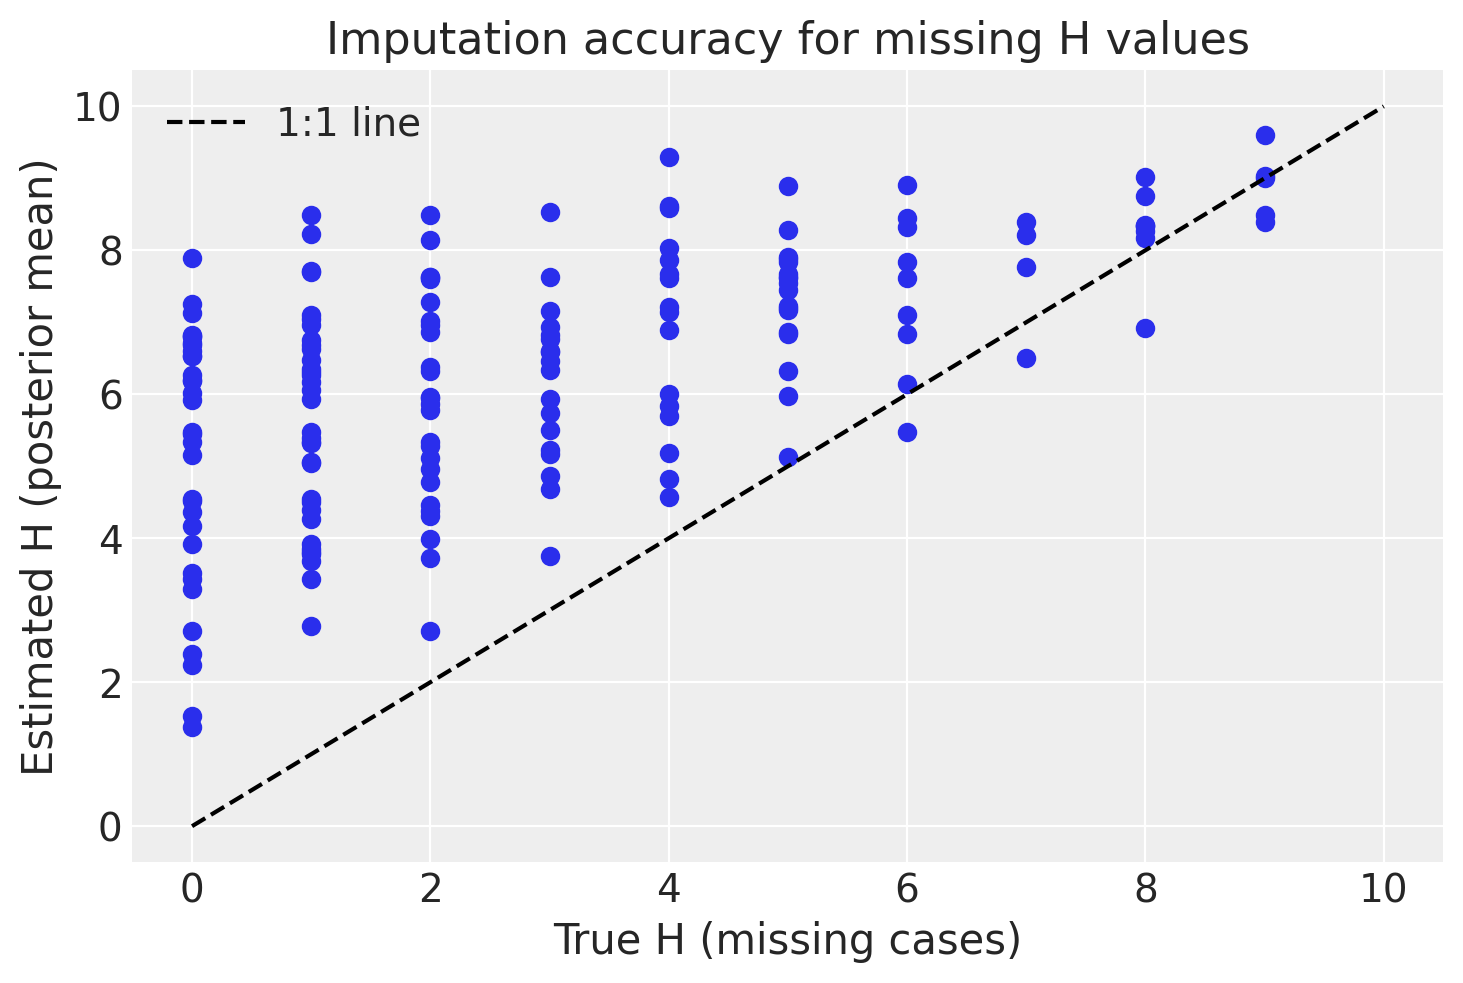

In [141]:
# Extract posterior samples for imputed H
H_missing_posterior = idata_mnar_x.posterior["H_unobserved"]  # shape: (chains, draws, n_missing)

# Compute posterior means
H_missing_mean = H_missing_posterior.mean(dim=("chain", "draw")).values
true_missing_H = H[D]

# Scatter plot: true vs estimated H for missing values
plt.scatter(true_missing_H, H_missing_mean)
plt.xlabel("True H (missing cases)")
plt.ylabel("Estimated H (posterior mean)")
plt.title("Imputation accuracy for missing H values")
plt.plot([0, 10], [0, 10], "k--", label="1:1 line")
plt.legend()
plt.show()

#### depends on H

In [142]:
N = 1000
S = rng.normal(size=N)  # Study effort (observed)

# Homework grade depends only on S (no X), coefficient before S is 1 and thus this is real effect
H = rng.binomial(n=10, p=invlogit(2 + S), size=N) 

p_miss = invlogit(-1 * (H - 6))  # Probability of missing increases as H decreases
D = rng.random(size=N) < p_miss

H_obs = H.astype(float)
H_obs[D] = np.nan

In [143]:
with pm.Model() as m15_4d:
    # Priors for study → homework
    a = pm.Normal("a", 0, 1)
    bS = pm.Normal("bS", 0, 0.5)

    # Linear model for P(H)
    p = pm.Deterministic("p", pm.math.sigmoid(a + bS * S))

    # Binomial outcome: homework completed
    H_latent = pm.Binomial("H", n=10, p=p, observed=H_obs)

    # Missingness model: D depends on H (which is partially latent!)
    d_alpha = pm.Normal("d_alpha", 0, 1)
    d_beta = pm.Normal("d_beta", -1, 0.5)  # Negative effect: lower H → more missing

    logit_p_miss = d_alpha + d_beta * H_latent
    p_miss = pm.Deterministic("p_miss", pm.math.sigmoid(logit_p_miss))

    # D: 1 if H was missing, 0 otherwise (observed indicator)
    D_obs = pm.Bernoulli("D", p=p_miss, observed=D.astype(int))

    idata_15_4d = pm.sample(return_inferencedata=True, random_seed=123)
az.summary(idata_15_4d)

/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/pymc/model/core.py:1295: RuntimeWarning: invalid value encountered in cast
  data = convert_observed_data(data).astype(rv_var.dtype)
Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [a, bS, d_alpha, d_beta]
>Metropolis: [H_unobserved]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 27 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/mnt/c/Users/risto/projects/pymc-resource

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,2.014,0.039,1.957,2.082,0.001,0.001,1235.0,1669.0,1.00
bS,0.997,0.040,0.933,1.059,0.001,0.001,970.0,1937.0,1.00
H_unobserved[0],7.698,1.251,6.000,9.000,0.046,0.030,768.0,853.0,1.00
H_unobserved[1],3.169,1.349,1.000,5.000,0.046,0.030,876.0,1028.0,1.00
H_unobserved[2],4.310,1.420,2.000,6.000,0.046,0.030,951.0,1039.0,1.01
...,...,...,...,...,...,...,...,...,...
p_miss[995],0.057,0.009,0.043,0.072,0.000,0.000,956.0,1800.0,1.00
p_miss[996],0.110,0.012,0.091,0.130,0.000,0.000,1422.0,2067.0,1.00
p_miss[997],0.057,0.009,0.043,0.072,0.000,0.000,956.0,1800.0,1.00
p_miss[998],0.029,0.006,0.019,0.039,0.000,0.000,840.0,1754.0,1.01


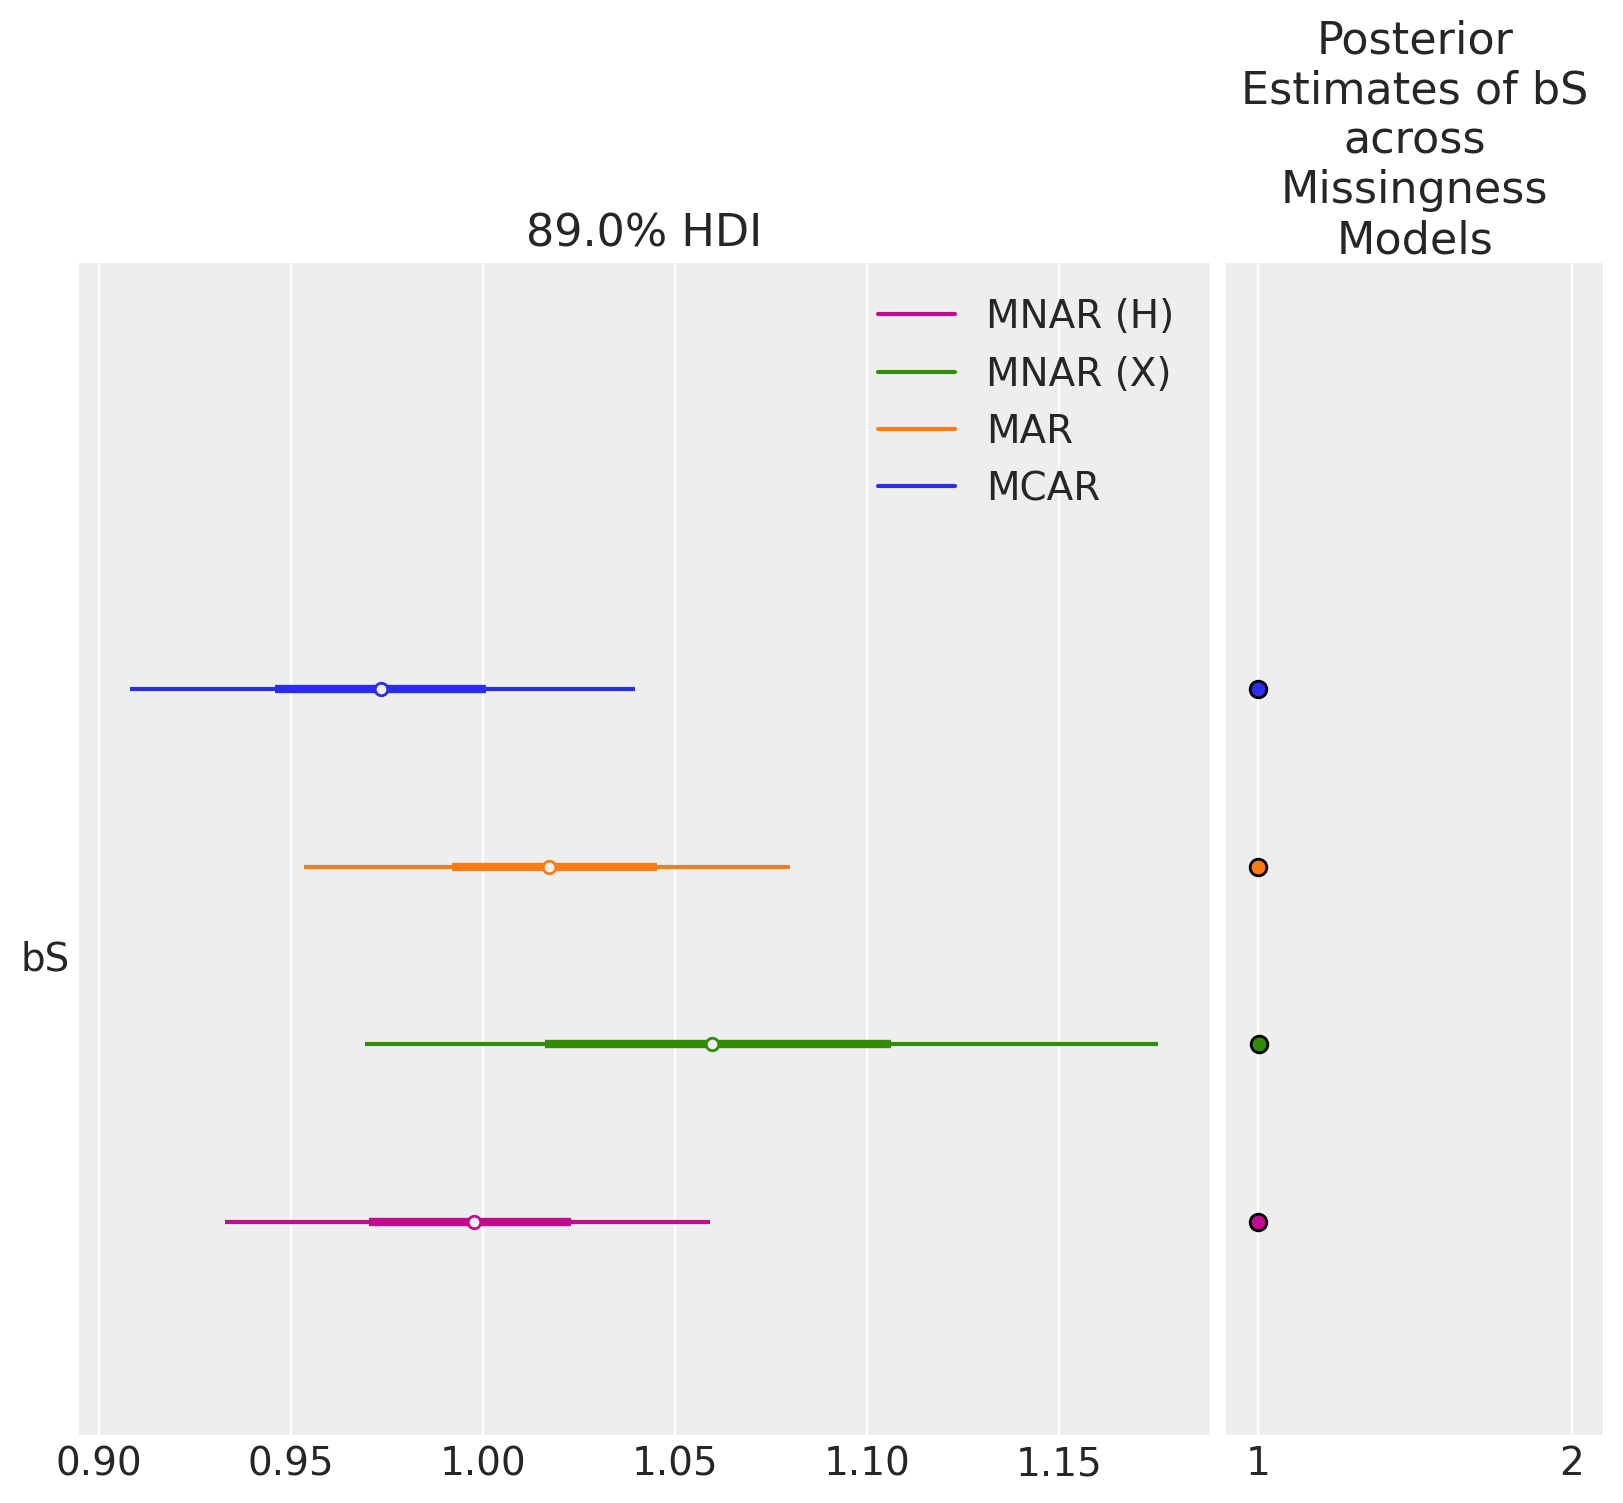

In [146]:
# Create a dictionary of all models
model_dict = {
    "MCAR": idata_mcar,
    "MAR": idata_mmar,
    "MNAR (X)": idata_mnar_x,
    "MNAR (H)": idata_15_4d,
}

# Plot forest plot to compare bS across models
az.plot_forest(
    list(model_dict.values()),
    model_names=list(model_dict.keys()),
    var_names=["bS"],
    combined=True,
    hdi_prob=0.89,
    r_hat=True,
)
plt.title("Posterior Estimates of bS across Missingness Models")
plt.show()

Each model recovers actual study effort which is close to 1

15H1.  The data in data(elephants) are counts of matings observed for bull elephants of differing ages. There is a strong positive relationship between age and matings. However, age is not always assessed accurately. First, fit a Poisson model predicting MATINGS with AGE as a predictor. Second, assume that the observed AGE values are uncertain and have a standard error of ±5 years. Re-estimate the relationship between MATINGS and AGE, incorporating this measurement error. Compare the inferences of the two models.

In [148]:
df_elef=pd.read_csv('End_of_chapter_problems/data/elephants.csv', sep=';')
df_elef.shape

(41, 2)

In [150]:
df_elef.head()

,AGE,MATINGS
0,27,0
1,28,1
2,28,1
3,28,1
4,28,3


<Axes: >

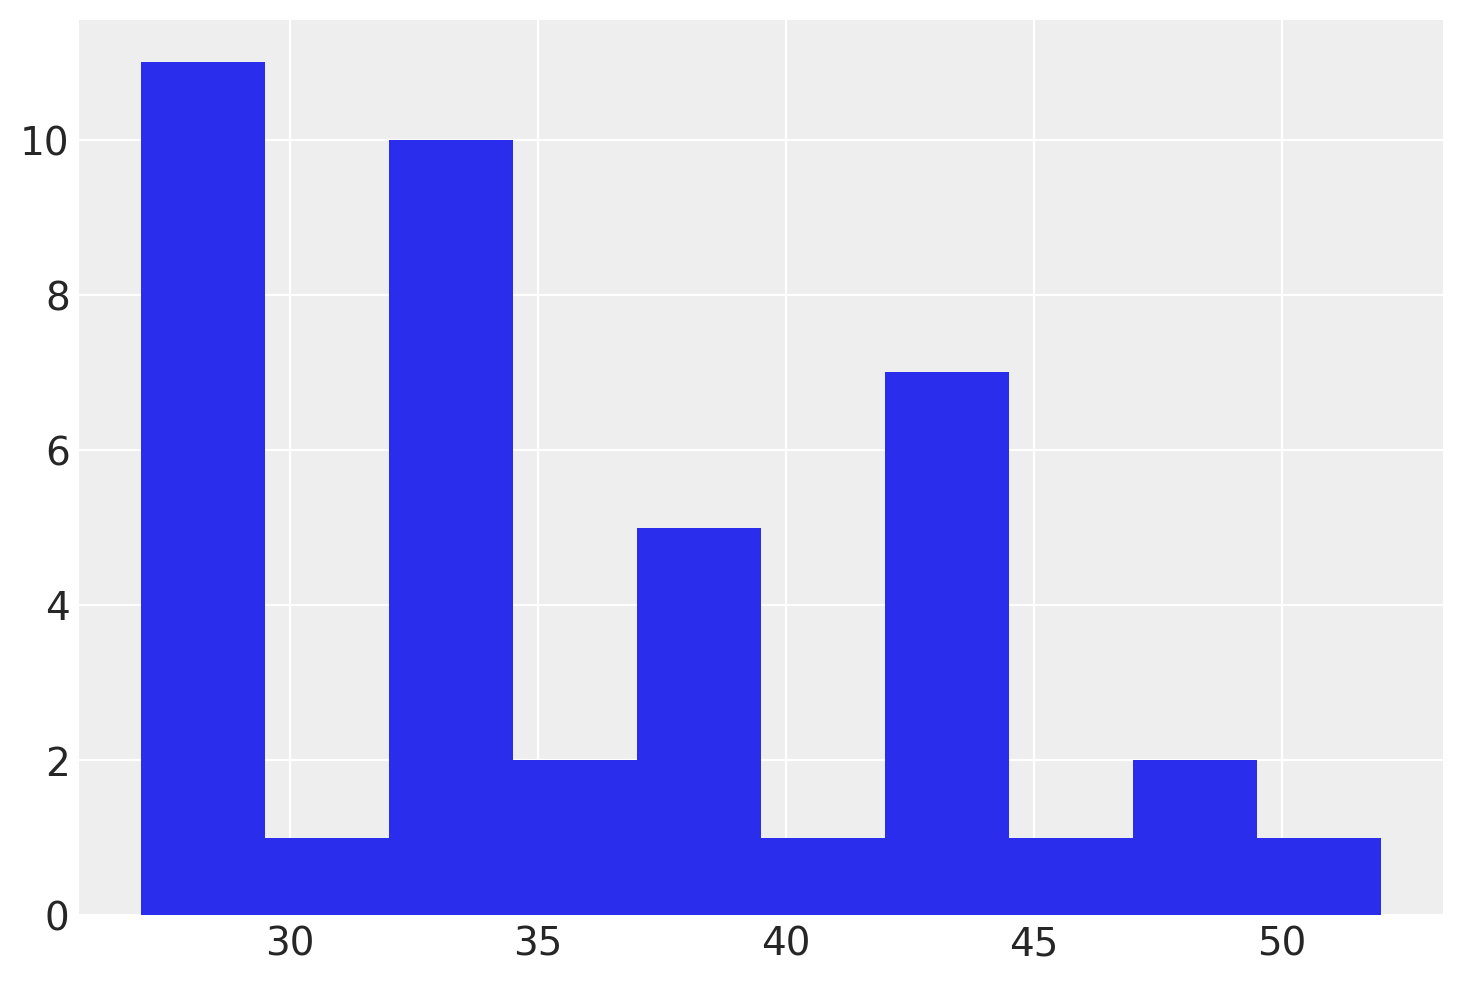

In [151]:
df_elef.AGE.hist()

In [156]:
with pm.Model() as m_elef:
    a = pm.Normal("a", 0, 1)
    b_age = pm.HalfNormal("b_age", 1.0)

    age =pm.Data("age", df_elef.AGE)

    lam = pm.math.exp(a + b_age * age)
    matings = pm.Poisson("matings", lam, observed=df_elef.MATINGS)
    trace_m_elef= pm.sample(random_seed=RANDOM_SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b_age]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [154]:
az.summary(trace_m_elef)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,-1.232,0.461,-1.995,-0.519,0.016,0.011,835.0,809.0,1.0
b_age,0.060,0.012,0.041,0.079,0.000,0.000,849.0,924.0,1.0


In [158]:
with pm.Model() as m_elef_err:
    # Priors
    a = pm.Normal("a", 0, 1)
    b_age = pm.Normal("b_age", 0, 1)  # or HalfNormal if you believe the effect is strictly positive

    # Latent true age (to be inferred)
    age_true = pm.Normal("age_true", mu=df_elef.AGE, sigma=5, shape=df_elef.shape[0])

    # Poisson rate using latent age
    lam = pm.math.exp(a + b_age * age_true)

    # Observed MATINGS
    matings = pm.Poisson("matings", mu=lam, observed=df_elef.MATINGS)

    trace_m_elef_err = pm.sample(random_seed=RANDOM_SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b_age, age_true]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


In [162]:
az.summary(trace_m_elef_err, var_names=["a", "b_age"])

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,-1.208,0.489,-1.971,-0.423,0.012,0.008,1796.0,2027.0,1.00
b_age,0.058,0.012,0.039,0.078,0.000,0.000,1761.0,2023.0,1.01


In [163]:
az.summary(trace_m_elef)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,-1.234,0.477,-2.015,-0.502,0.020,0.016,570.0,554.0,1.01
b_age,0.060,0.012,0.040,0.079,0.001,0.000,564.0,526.0,1.01


Both models estimate a similar positive relationship between AGE and MATINGS. Introducing measurement error in AGE with a standard deviation of 5 years has little effect on the posterior for b_age, suggesting the error is modest relative to the overall variation in AGE. This implies that the model's inferences are robust to this level of measurement uncertainty in this case.

15H2.  Repeat the model fitting problem above, now increasing the assumed standard error on AGE. How large does the standard error have to get before the posterior mean for the coefficient on AGE reaches zero?

In [186]:
with pm.Model() as m_elef_err_v2:
    # Priors
    a = pm.Normal("a", 0, 1)
    b_age = pm.Normal("b_age", 0, 1)  # or HalfNormal if you believe the effect is strictly positive

    # Latent true age (to be inferred)
    age_true = pm.Normal("age_true", mu=df_elef.AGE, sigma=80, shape=df_elef.shape[0])

    # Poisson rate using latent age
    lam = pm.math.exp(a + b_age * age_true)

    # Observed MATINGS
    matings = pm.Poisson("matings", mu=lam, observed=df_elef.MATINGS)

    trace_m_elef_err_v2 = pm.sample(random_seed=RANDOM_SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b_age, age_true]


Output()

/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
There were 870 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [187]:
az.summary(trace_m_elef_err_v2, var_names=["a", "b_age"])

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.651,0.261,0.288,1.129,0.093,0.039,9.0,32.0,1.37
b_age,0.005,0.006,-0.007,0.011,0.002,0.002,9.0,30.0,1.37


when sigma is very bg (around 80) does it reach to 0

5H3.  The fact that information flows in all directions among parameters sometimes leads to rather unintuitive conclusions. Here’s an example from missing data imputation, in which imputation of a single datum reverses the direction of an inferred relationship. Use these data:

R code 15.32

set.seed(100)

x <- c( rnorm(10) , NA )

y <- c( rnorm(10,x) , 100 )

d <- list(x=x,y=y)

These data comprise 11 cases, one of which has a missing predictor value. You can quickly confirm that a regression of y on x for only the complete cases indicates a strong positive relationship between the two variables. But now fit this model, imputing the one missing value for x:

 

Be sure to run multiple chains. What happens to the posterior distribution of β? Be sure to inspect the full density. Can you explain the change in inference?

In [190]:
# Generate x with 10 normal values and 1 missing
x = np.append(rng.normal(size=10), np.nan)

# Generate y with 10 normal values centered on x[0:10] and one outlier (100)
y = np.append(rng.normal(loc=x[:10]), 100)

# Bundle into dictionary
d = pd.DataFrame({"x": x, "y": y})

<Axes: xlabel='x', ylabel='y'>

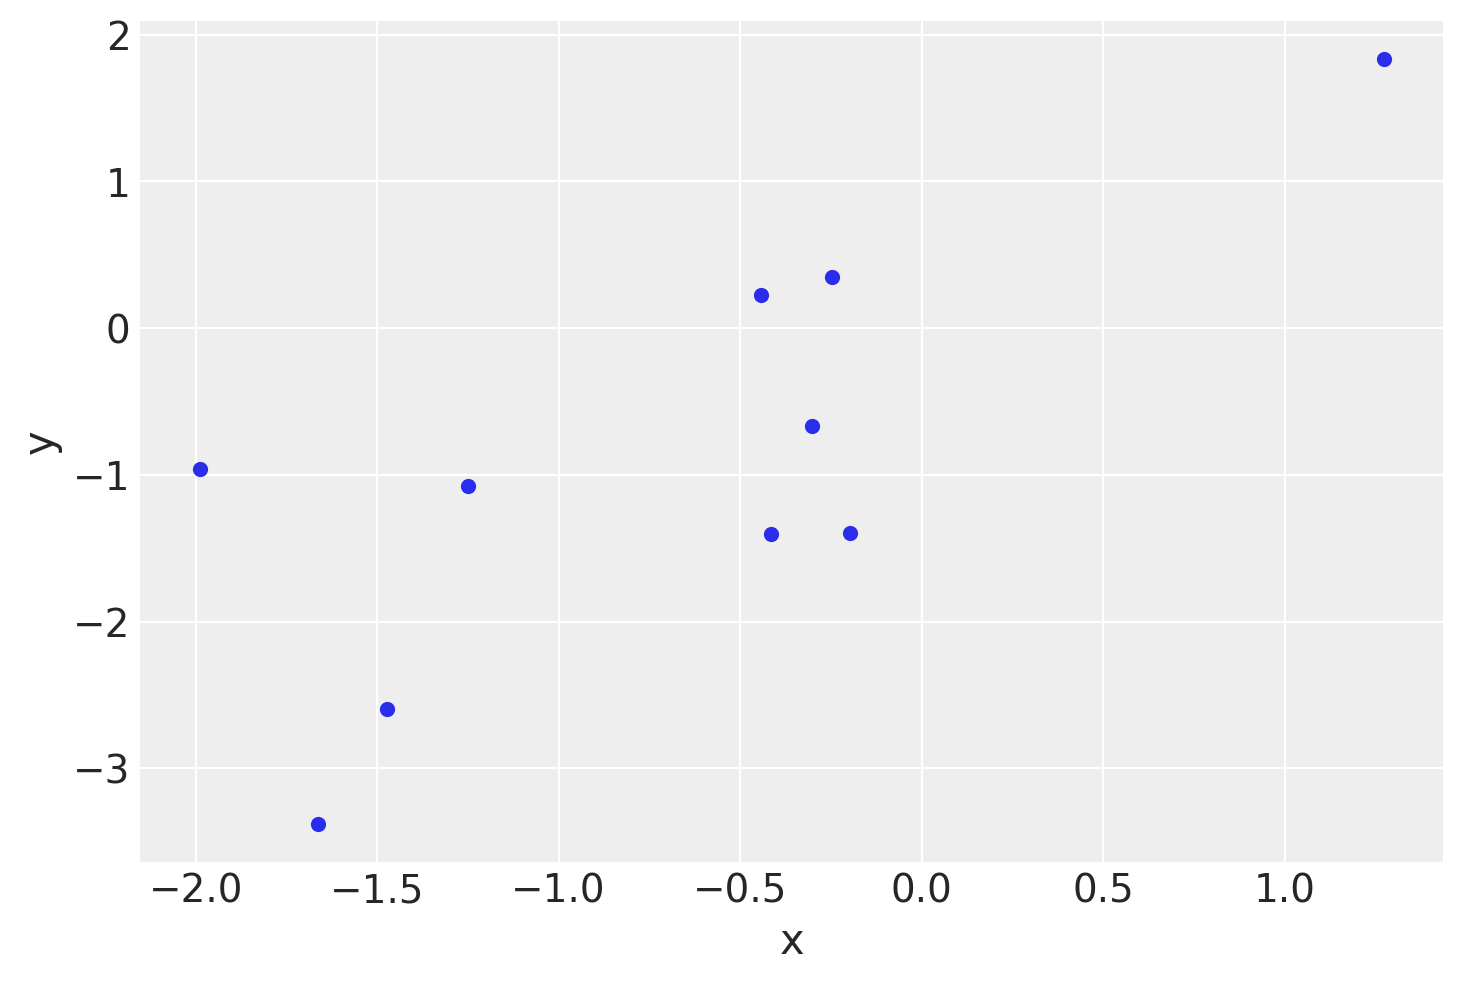

In [204]:
d.plot.scatter(x="x", y="y")

In [191]:
d

,x,y
0,-1.663355,-3.379718
1,-0.198292,-1.399025
2,-1.248600,-1.077953
3,-0.300864,-0.664553
4,-0.247265,0.350942
5,-1.989282,-0.961163
6,1.273994,1.834535
7,-0.415520,-1.400223
8,-1.473560,-2.593435
9,-0.441998,0.228188


In [193]:
d_complete=d.dropna()
d_complete

,x,y
0,-1.663355,-3.379718
1,-0.198292,-1.399025
2,-1.248600,-1.077953
3,-0.300864,-0.664553
4,-0.247265,0.350942
5,-1.989282,-0.961163
6,1.273994,1.834535
7,-0.415520,-1.400223
8,-1.473560,-2.593435
9,-0.441998,0.228188


In [205]:
with pm.Model() as m_complete:
    sigma = pm.Normal("sigma", 1)
    a = pm.Normal("a", 0, 1)
    b = pm.Normal("b", 0, 1)

    x=pm.Data("x", d_complete.x.values)

    mu=a+b*x
    Y = pm.Normal("Y", mu, sigma, observed=d_complete.y.values)

    trace_m_complete = pm.sample(random_seed=RANDOM_SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, a, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
There were 1 divergences after tuning. Increase `target_accept` or reparameterize.


In [206]:
az.summary(trace_m_complete)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,1.141,0.311,0.697,1.567,0.008,0.010,1811.0,1503.0,1.0
a,-0.174,0.399,-0.764,0.489,0.009,0.008,1798.0,2055.0,1.0
b,1.053,0.369,0.435,1.610,0.009,0.007,1712.0,1878.0,1.0


In [207]:
with pm.Model() as m_missing:
    sigma = pm.Normal("sigma", 1)
    a = pm.Normal("a", 0, 100)
    b = pm.Normal("b", 0, 100)

    # x=pm.Data("x",observed= d.x.values)
    x =pm.Normal("x", 0,1, observed=d.x.values)

    mu=a+b*x
    Y = pm.Normal("Y", mu, sigma, observed=d.y.values)

    trace_m_missing = pm.sample(random_seed=RANDOM_SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, a, b, x_unobserved]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [208]:
az.summary(trace_m_missing)

/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,6.351,0.679,5.353,7.473,0.174,0.037,16.0,69.0,1.17
a,5.333,7.879,-9.453,12.834,3.786,2.136,7.0,31.0,1.53
b,6.612,11.811,-14.493,15.567,5.847,3.359,7.0,34.0,1.53
x_unobserved[0],2.632,5.184,-6.682,6.624,2.562,1.468,7.0,29.0,1.53
x[0],-1.663,0.000,-1.663,-1.663,0.000,0.000,4000.0,4000.0,NaN
x[1],-0.198,0.000,-0.198,-0.198,0.000,0.000,4000.0,4000.0,NaN
x[2],-1.249,0.000,-1.249,-1.249,0.000,NaN,4000.0,4000.0,NaN
x[3],-0.301,0.000,-0.301,-0.301,0.000,0.000,4000.0,4000.0,NaN
x[4],-0.247,0.000,-0.247,-0.247,0.000,0.000,4000.0,4000.0,NaN
x[5],-1.989,0.000,-1.989,-1.989,0.000,0.000,4000.0,4000.0,NaN


with imputation as y has extereme value for missing case we get very wide confidence intervals and no clear positive effect.

In the complete-case model, the relationship between x and y was clearly positive. But when we impute the missing x using a full Bayesian model, the extreme value of y=100 dominates the inference for x[11]. As a result, the posterior for the slope b becomes extremely uncertain and effectively uninformative — showing that information flows in both directions in a joint model.

15H4. Using data(Primates301), consider the relationship between brain volume (brain) and body mass (body). These variables are presented as single values for each species. However, there is always a range of sizes in a species, and some of these measurements are taken from very small samples. So these values are measured with some unknown error.

We don’t have the raw measurements to work with—that would be best. But we can imagine what might happen if we had them. Suppose error is proportional to the measurement. This makes sense, because larger animals have larger variation. As a consequence, the uncertainty is not uniform across the values and this could mean trouble.

Let’s make up some standard errors for these measurements, to see what might happen. Load the data and scale the the measurements so the maximum is 1 in both cases:

R code 15.33

library(rethinking)

data(Primates301)

d <- Primates301

cc <- complete.cases( d$brain , d$body )

B <- d$brain[cc]

M <- d$body[cc]

B <- B / max(B)

M <- M / max(M)

Now I’ll make up some standard errors for B and M, assuming error is 10% of the measurement.

R code 15.34

Bse <- B*0.1

Mse <- M*0.1

Let’s model these variables with this relationship:

$B_i \sim \text{LogNormal}(\mu_i, \sigma)$  
$\mu_i = \alpha + \beta \log M_i$


This says that brain volume is a log-normal variable, and the mean on the log scale is given by μ. What this model implies is that the expected value of B is

$\mathbb{E}(B_i \mid M_i) = \exp(\alpha) M_i^{\beta}$

So this is a standard allometric scaling relationship—incredibly common in biology.

Ignoring measurement error, the corresponding ulam model is:

dat_list <- list( B = B , M = M )

m15H4 <- ulam(

 alist(

  B ~ dlnorm( mu , sigma ),

  mu <- a + b*log(M),

  a ~ normal(0,1),

  b ~ normal(0,1),

  sigma ~ exponential(1)

 ) , data=dat_list )


 Your job is to add the measurement errors to this model. Use the divorce/marriage example in the chapter as a guide. It might help to initialize the unobserved true values of B and M using the observed values, by adding a list like this to ulam:

 R code 15.36

start=list( M_true=dat_list$M , B_true=dat_list$B )

Compare the inference of the measurement error model to those of m1.1 above. Has anything changed? Why or why not?

In [209]:
df_prim=pd.read_csv('Data/Primates301.csv', sep=';')
df_prim.shape

(301, 16)

In [210]:
df_prim.head()

,name,genus,species,subspecies,spp_id,genus_id,social_learning,research_effort,brain,body,group_size,gestation,weaning,longevity,sex_maturity,maternal_investment
0,Allenopithecus_nigroviridis,Allenopithecus,nigroviridis,NaN,1,1,0.0,6.0,58.02,4655.00,40.0,NaN,106.15,276.0,NaN,NaN
1,Allocebus_trichotis,Allocebus,trichotis,NaN,2,2,0.0,6.0,NaN,78.09,1.0,NaN,NaN,NaN,NaN,NaN
2,Alouatta_belzebul,Alouatta,belzebul,NaN,3,3,0.0,15.0,52.84,6395.00,7.4,NaN,NaN,NaN,NaN,NaN
3,Alouatta_caraya,Alouatta,caraya,NaN,4,3,0.0,45.0,52.63,5383.00,8.9,185.92,323.16,243.6,1276.72,509.08
4,Alouatta_guariba,Alouatta,guariba,NaN,5,3,0.0,37.0,51.70,5175.00,7.4,NaN,NaN,NaN,NaN,NaN


In [216]:
df_prim_bb=df_prim[['brain', 'body']].dropna()
df_prim_bb.shape

(182, 2)

In [217]:
df_prim_bb.head()

,brain,body
0,58.02,4655.0
2,52.84,6395.0
3,52.63,5383.0
4,51.70,5175.0
5,49.88,6250.0


In [218]:
df_prim_bb['brain']=df_prim_bb.brain/df_prim_bb.brain.max()
df_prim_bb['body']=df_prim_bb.body/df_prim_bb.body.max()

In [219]:
df_prim_bb.head()

,brain,body
0,0.118102,0.035808
2,0.107558,0.049192
3,0.107130,0.041408
4,0.105237,0.039808
5,0.101533,0.048077


In [235]:
B_se=df_prim_bb.brain*0.1
M_se=df_prim_bb.body*0.1

In [236]:
with pm.Model() as m_no_error:
    a = pm.Normal("a", 0, 1)
    b = pm.Normal("b", 0, 1)
    sigma = pm.Exponential("sigma", 1)

    mu = a + b * np.log(df_prim_bb.body)  # M is the scaled body mass array

    B_obs = pm.Lognormal("B_obs", mu=mu, sigma=sigma, observed=df_prim_bb.brain)  # B is the scaled brain mass array

    trace_no_error = pm.sample(random_seed=RANDOM_SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [237]:
az.summary(trace_no_error)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.427,0.057,0.342,0.524,0.001,0.001,1586.0,1436.0,1.0
b,0.783,0.014,0.762,0.807,0.000,0.000,1620.0,1490.0,1.0
sigma,0.293,0.016,0.269,0.320,0.000,0.000,2016.0,1815.0,1.0


In [238]:
with pm.Model() as m_error:
    # Priors
    a = pm.Normal("a", 0, 1)
    b = pm.Normal("b", 0, 1)
    sigma = pm.Exponential("sigma", 1)

    # Latent true M values
    M_true = pm.Normal("M_true", mu=0, sigma=1, shape=df_prim_bb.shape[0])

    # Structural model: log(B) = a + b * log(M_true)
    mu = a + b * pm.math.log(df_prim_bb.body.values)

    # Brain volume is log-normally distributed around mu
    B_obs = pm.Lognormal("B_obs", mu=mu, sigma=sigma, observed=df_prim_bb.brain.values)

    # Observed M values given true M and standard errors
    M_obs = pm.Normal("M_obs", mu=M_true, sigma=M_se, observed=df_prim_bb.body.values)

    trace_error = pm.sample(random_seed=RANDOM_SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, sigma, M_true]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


In [234]:
az.summary(trace_error)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.428,0.060,0.329,0.519,0.001,0.001,7331.0,2895.0,1.00
b,0.783,0.014,0.760,0.806,0.000,0.000,7069.0,3003.0,1.00
M_true[0],0.036,0.011,0.018,0.053,0.000,0.000,10506.0,2126.0,1.01
M_true[1],0.049,0.015,0.027,0.074,0.000,0.000,10873.0,2650.0,1.00
M_true[2],0.041,0.012,0.023,0.061,0.000,0.000,10392.0,3130.0,1.00
...,...,...,...,...,...,...,...,...,...
M_true[178],0.090,0.028,0.046,0.133,0.000,0.001,8759.0,2433.0,1.00
M_true[179],0.048,0.014,0.025,0.071,0.000,0.000,8150.0,2953.0,1.00
M_true[180],0.027,0.008,0.014,0.039,0.000,0.000,8854.0,2512.0,1.00
M_true[181],0.028,0.008,0.014,0.041,0.000,0.000,8107.0,2634.0,1.00


15H5.  Now consider missing values—this data set is lousy with them. You can ignore measurement error in this problem. Let’s get a quick idea of the missing values by counting them in each variable: R code

R code 15.37

library(rethinking)

data(Primates301)

d <- Primates301

colSums( is.na(d) )

We’ll continue to focus on just brain and body, to stave off insanity. Consider only those species with measured body masses:

R code 15.38

cc <- complete.cases( d$body )

M <- d$body[cc]

M <- M / max(M)

B <- d$brain[cc]

B <- B / max( B , na.rm=TRUE )

You should end up with 238 species and 56 missing brain values among them.

First, consider whether there is a pattern to the missing values. Does it look like missing values are associated with particular values of body mass? Draw a DAG that represents how missingness works in this case. Which type (MCAR, MAR, MNAR) is this?

Second, impute missing values for brain size. It might help to initialize the 56 imputed variables to a valid value:

R code 15.39

start=list( B_impute=rep(0.5,56) )

This just helps the chain get started.

Compare the inferences to an analysis that drops all the missing values. Has anything changed? Why or why not? Hint: Consider the density of data in the ranges where there are missing values. You might want to plot the imputed brain sizes together with the observed values.

In [240]:
df_prim.isnull().sum()

name                     0
genus                    0
species                  0
subspecies             267
spp_id                   0
genus_id                 0
social_learning         98
research_effort        115
brain                  117
body                    63
group_size             114
gestation              161
weaning                185
longevity              181
sex_maturity           194
maternal_investment    197
dtype: int64

In [243]:
df_prim2=df_prim[['body', 'brain']]
df_prim2=df_prim2[~pd.isnull(df_prim2.body)]
df_prim2.shape

(238, 2)

In [245]:
df_prim2['body']=df_prim2['body']/df_prim2['body'].max()
df_prim2['brain']=df_prim2['brain']/df_prim2['brain'].max()

In [247]:
df_prim2.isnull().sum()

body      0
brain    56
dtype: int64

<Axes: xlabel='body', ylabel='Density'>

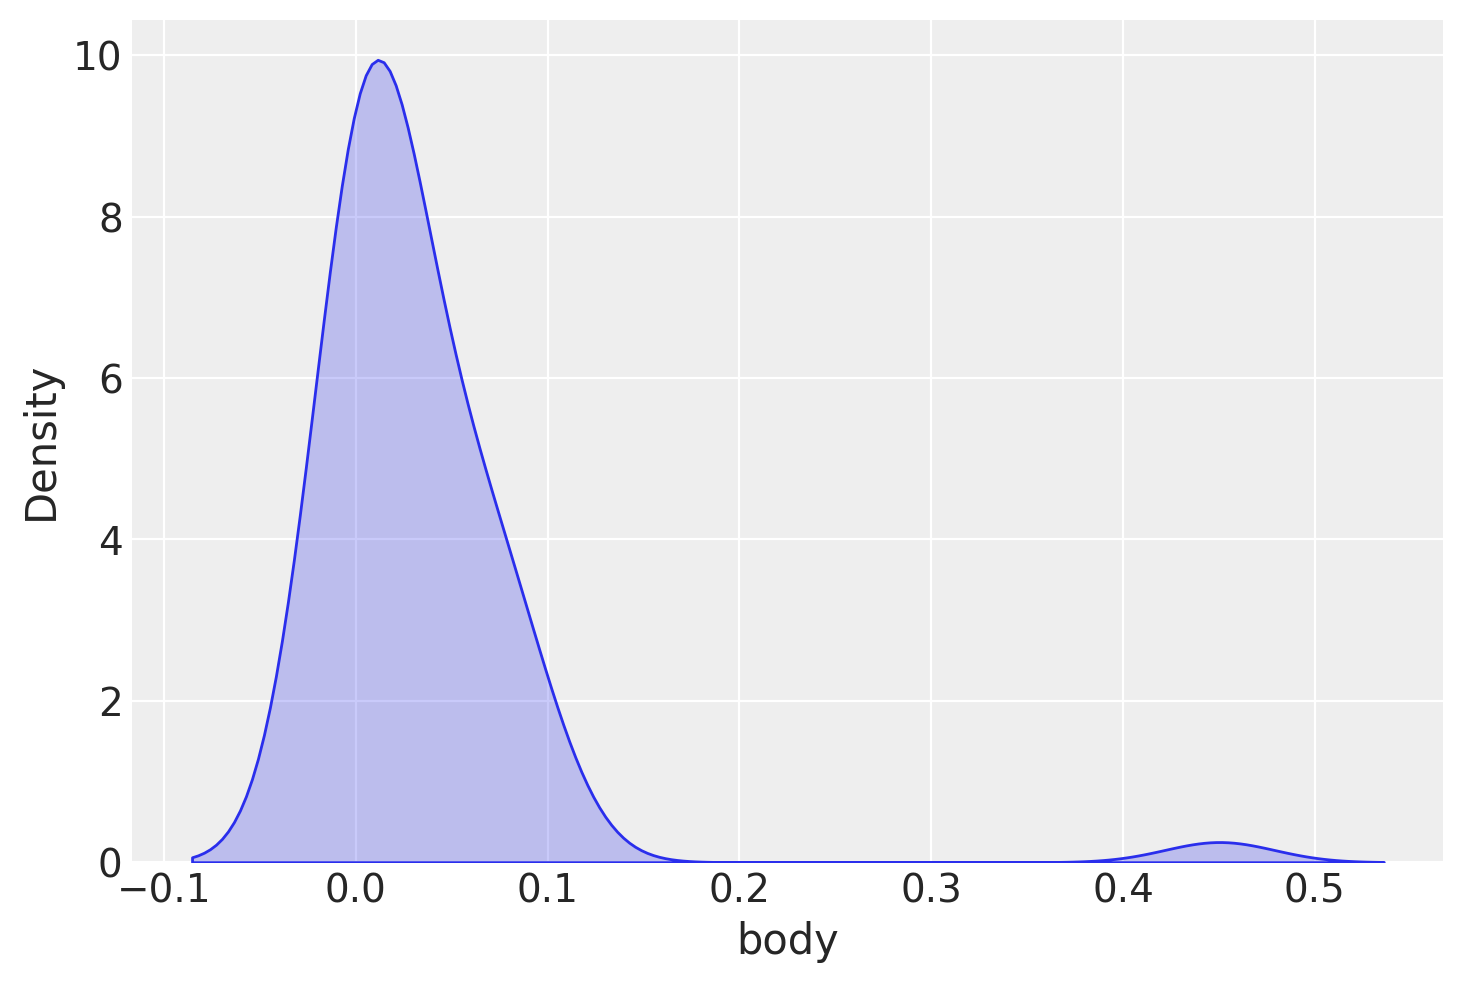

In [256]:
sns.kdeplot(df_prim2[pd.isnull(df_prim2["brain"])]["body"].dropna(), fill=True)

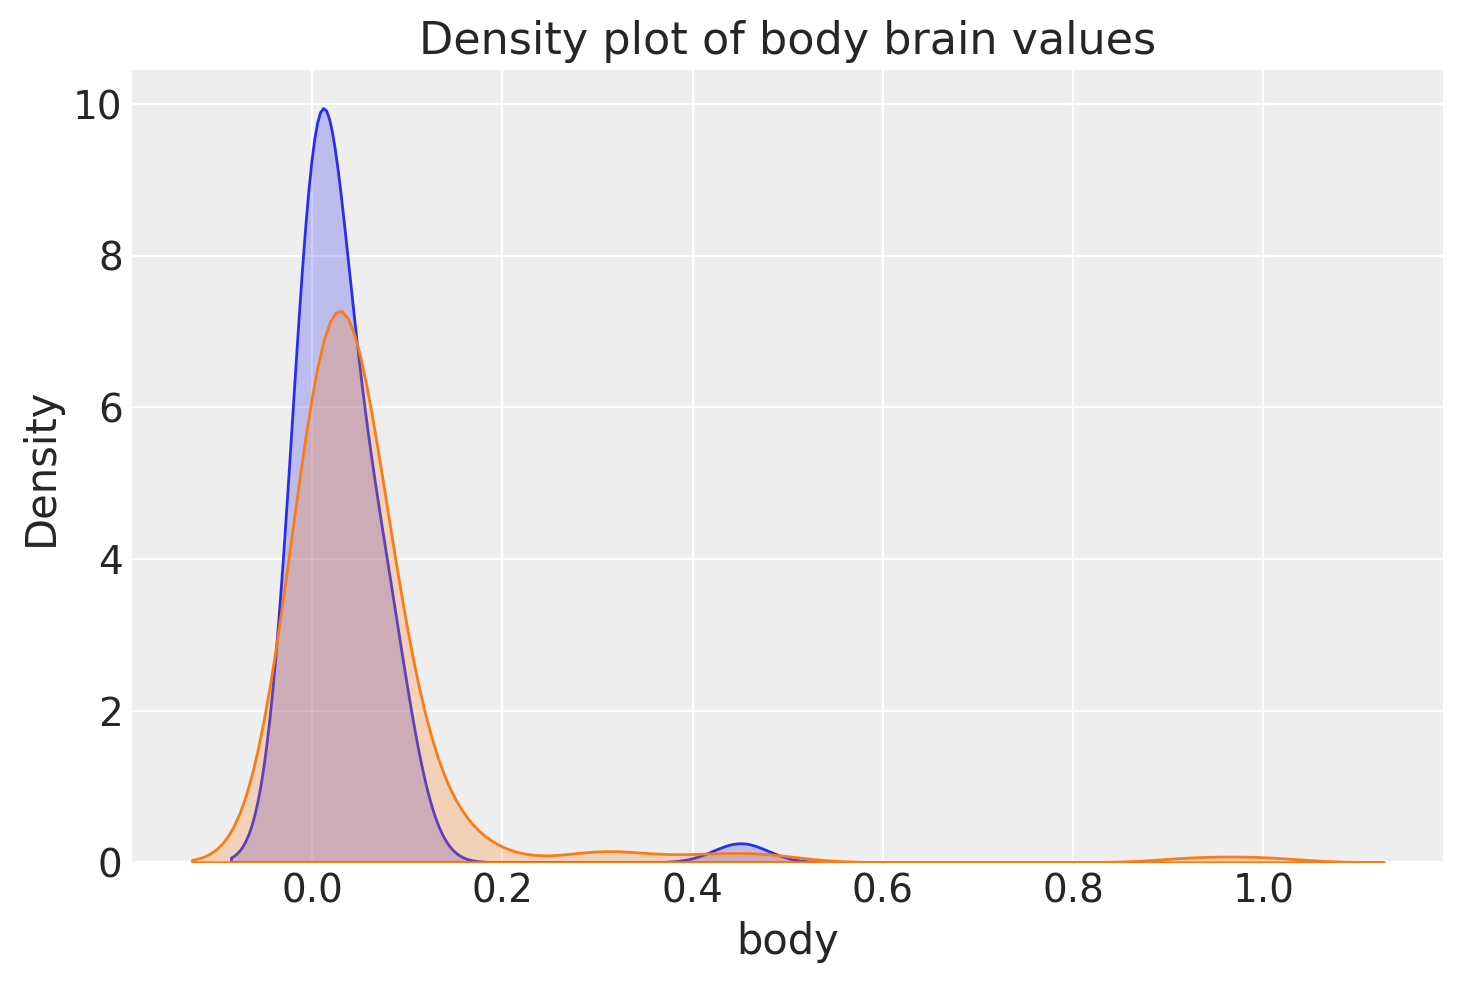

In [255]:
import seaborn as sns
sns.kdeplot(df_prim2[pd.isnull(df_prim2["brain"])]["body"].dropna(), fill=True)
sns.kdeplot(df_prim2[~pd.isnull(df_prim2["brain"])]["body"].dropna(), fill=True)
plt.xlabel("body")
plt.title("Density plot of body brain values")
plt.show()

In [257]:
M = df_prim2["body"].values
B = df_prim2["brain"].values  # this includes NaNs

with pm.Model() as m_impute_brain:
    a = pm.Normal("a", 0, 1)
    b = pm.Normal("b", 0, 1)
    sigma = pm.Exponential("sigma", 1)

    mu = a + b * np.log(M)

    B_obs = pm.Lognormal("B", mu=mu, sigma=sigma, observed=B)

    trace = pm.sample(random_seed=123, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, sigma, B_unobserved]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


In [258]:
az.summary(trace)

/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4
/mnt/c/Users/risto/projects/pymc-resources/.venv/lib/python3.12/site-packages/arviz/stats/diagnost

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.426,0.059,0.328,0.515,0.001,0.001,4265.0,3486.0,1.0
b,0.783,0.014,0.761,0.805,0.000,0.000,4009.0,3510.0,1.0
sigma,0.293,0.016,0.267,0.316,0.000,0.000,4457.0,3468.0,1.0
B_unobserved[0],0.005,0.002,0.003,0.007,0.000,0.000,7037.0,2578.0,1.0
B_unobserved[1],0.030,0.009,0.015,0.042,0.000,0.000,12070.0,3176.0,1.0
...,...,...,...,...,...,...,...,...,...
B[233],0.148,0.000,0.148,0.148,0.000,0.000,4000.0,4000.0,NaN
B[234],0.211,0.000,0.211,0.211,0.000,NaN,4000.0,4000.0,NaN
B[235],0.125,0.000,0.125,0.125,0.000,0.000,4000.0,4000.0,NaN
B[236],0.063,0.000,0.063,0.063,0.000,0.000,4000.0,4000.0,NaN


In [259]:
az.summary(trace_error)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.427,0.060,0.329,0.520,0.001,0.001,6588.0,2860.0,1.0
b,0.783,0.014,0.761,0.807,0.000,0.000,6756.0,2930.0,1.0
M_true[0],0.036,0.004,0.030,0.042,0.000,0.000,10729.0,2679.0,1.0
M_true[1],0.049,0.005,0.041,0.057,0.000,0.000,10175.0,2841.0,1.0
M_true[2],0.041,0.004,0.034,0.048,0.000,0.000,11364.0,2568.0,1.0
...,...,...,...,...,...,...,...,...,...
M_true[178],0.091,0.009,0.076,0.105,0.000,0.000,10646.0,2391.0,1.0
M_true[179],0.048,0.005,0.041,0.056,0.000,0.000,10071.0,3133.0,1.0
M_true[180],0.027,0.003,0.023,0.031,0.000,0.000,9706.0,2692.0,1.0
M_true[181],0.027,0.003,0.023,0.032,0.000,0.000,12290.0,2311.0,1.0


Upon inspecting the missing values, it appears that species with smaller body mass are more likely to be missing brain volume data. This suggests that the missingness is not completely random. Since body size is observed and predictive of missingness in brain size, the missing data mechanism is best characterized as Missing At Random (MAR).

15H6.  Return to the divorce rate measurement error model. This time try to incorporate the full generative system: A → M → D, A → D. What this means is that the prior for M should include A somehow, because it is influenced by A.

In [260]:
d = pd.read_csv("Data/WaffleDivorce.csv", sep=";")
D_obs = standardize(d["Divorce"])
D_sd = d["Divorce SE"] / d["Divorce"].std()
M = standardize(d["Marriage"])
A = standardize(d["MedianAgeMarriage"])
N = len(d)

In [262]:
D_obs = standardize(d["Divorce"])
D_sd = d["Divorce SE"] / d["Divorce"].std()
M_obs = standardize(d["Marriage"])
M_sd = d["Marriage SE"] / d["Marriage"].std()
A = standardize(d["MedianAgeMarriage"])
N = len(d)

with pm.Model() as m15_2_full:
    sigma = pm.Exponential("sigma", 1)
    bM = pm.Normal("bM", 0, 0.5)
    bA = pm.Normal("bA", 0, 0.5)
    a = pm.Normal("a", 0, 0.2)

    bAM = pm.Normal("bAM", 0, 0.5)  # A → M
    aM = pm.Normal("aM", 0, 0.5)    # intercept for A → M
    M_true = pm.Normal("M_true", mu=aM + bAM * A, sigma=1)

    mu = a + bA * A + bM * M_true  # linear model
    D_true = pm.Normal("D_true", mu, sigma, shape=N)  # distribution for true D values

    D = pm.Normal("D_obs", D_true, D_sd, observed=D_obs)  # distribution for observed D values
    M = pm.Normal("M_obs", M_true, M_sd, observed=M_obs)  # distribution for observed M values

    idata_m15_2_full = pm.sample(return_inferencedata=True, random_seed=RANDOM_SEED)

az.summary(idata_m15_2_full, var_names=["~D_true", "~M_true"], round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, bM, bA, a, bAM, aM, M_true, D_true]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
There were 1 divergences after tuning. Increase `target_accept` or reparameterize.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
bM,0.14,0.20,-0.17,0.47,0.0,0.0,2288.94,3321.91,1.0
bA,-0.56,0.17,-0.84,-0.30,0.0,0.0,3280.17,3044.41,1.0
a,-0.04,0.10,-0.21,0.10,0.0,0.0,5965.82,3002.32,1.0
bAM,-0.64,0.15,-0.88,-0.40,0.0,0.0,6161.82,2903.20,1.0
aM,-0.05,0.15,-0.29,0.18,0.0,0.0,8837.72,2705.44,1.0
sigma,0.58,0.11,0.40,0.74,0.0,0.0,1324.92,2235.57,1.0


In [266]:
az.summary(idata_m15_2, var_names=["a", "bA", "bM", "sigma"], round_to=2)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,-0.04,0.10,-0.20,0.11,0.0,0.0,4910.79,2967.39,1.0
bA,-0.55,0.16,-0.79,-0.28,0.0,0.0,3337.59,3573.89,1.0
bM,0.20,0.21,-0.14,0.53,0.0,0.0,2318.87,2612.11,1.0
sigma,0.56,0.11,0.38,0.73,0.0,0.0,1239.25,911.72,1.0


Estimates did not change much

15H7.  Some lad named Andrew made an eight-sided spinner. He wanted to know if it is fair. So he spun it a bunch of times, recording the counts of each value. Then he accidentally spilled coffee over the 4s and 5s. The surviving data are summarized below.

Value

1

2

3

4

5

6

7

8

Frequency

18

19

22

NA

NA

19

20

22

Your job is to impute the two missing values in the table above. Andrew doesn’t remember how many times he spun the spinner. So you will have to assign a prior distribution for the total number of spins and then marginalize over the unknown total. Andrew is not sure the spinner is fair (every value is equally likely), but he’s confident that none of the values is twice as likely as any other. Use a Dirichlet distribution to capture this prior belief. Plot the joint posterior distribution of 4s and 5s.

In [269]:
spinner_data = [
    {"value": 1, "frequency": 18},
    {"value": 2, "frequency": 19},
    {"value": 3, "frequency": 22},
    {"value": 4, "frequency": np.nan},  # missing
    {"value": 5, "frequency": np.nan},  # missing
    {"value": 6, "frequency": 19},
    {"value": 7, "frequency": 20},
    {"value": 8, "frequency": 22},
]

df_spinner = pd.DataFrame(spinner_data)
df_spinner['value_norm']=pd.Categorical(df_spinner.value).codes
df_spinner

,value,frequency,value_norm
0,1,18.0,0
1,2,19.0,1
2,3,22.0,2
3,4,NaN,3
4,5,NaN,4
5,6,19.0,5
6,7,20.0,6
7,8,22.0,7


<Axes: >

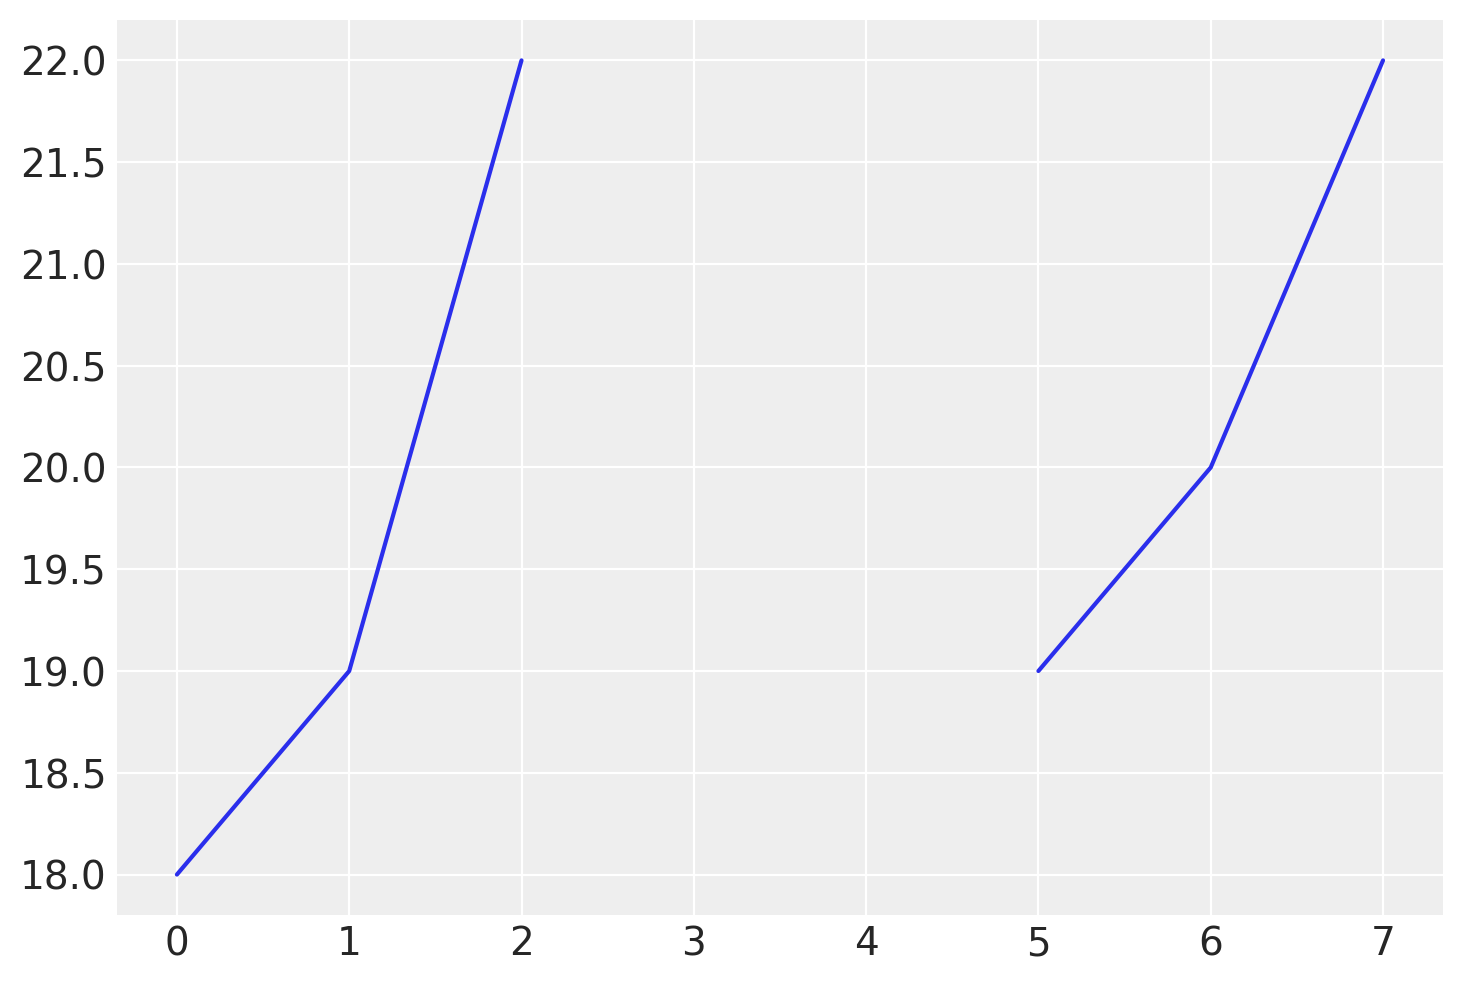

In [268]:
df_spinner.frequency.plot()

solution taken from here and with the help of chat gpt

In [282]:
import pytensor.tensor as pt

In [294]:
# Observed spinner counts (None for values 4 and 5)
counts = np.array([18, 19, 22, None, None, 19, 20, 22], dtype=object)
S_mean = 160
observed_sum = sum([c for c in counts if c is not None])
y_max = 50

with pm.Model() as m_spinner_marginal:
    # Dirichlet prior over outcome probabilities
    p = pm.Dirichlet("p", a=np.repeat(50.0, 8))

    # Latent counts for outcomes 4 and 5
    x4 = pm.DiscreteUniform("x4", lower=0, upper=y_max)
    x5 = pm.DiscreteUniform("x5", lower=0, upper=y_max)

    # Poisson prior on total unknown spins
    pm.Potential("poisson_total", pm.logprob.logp(pm.Poisson.dist(mu=S_mean - observed_sum), x4 + x5))

    # Combine all counts
    full_counts = pt.stack([
        counts[0], counts[1], counts[2], x4, x5,
        counts[5], counts[6], counts[7]
    ])
    total_spins = pt.sum(full_counts)

    # Multinomial likelihood
    pm.Potential("likelihood", pm.logprob.logp(pm.Multinomial.dist(n=total_spins, p=p), full_counts))

    # Explicitly set Metropolis step for discrete model
    trace = pm.sample(2000, step=pm.Metropolis(), random_seed=123, return_inferencedata=True)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [p]
>Metropolis: [x4]
>Metropolis: [x5]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 2 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [295]:
az.summary(trace)

,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x4,19.878,4.516,12.000,26.000,0.180,0.082,631.0,1195.0,1.01
x5,19.746,4.523,12.000,26.000,0.176,0.089,663.0,1224.0,1.01
p[0],0.121,0.014,0.098,0.144,0.001,0.000,492.0,735.0,1.01
p[1],0.124,0.014,0.101,0.146,0.001,0.000,589.0,829.0,1.00
p[2],0.129,0.015,0.106,0.152,0.001,0.000,580.0,677.0,1.01
p[3],0.125,0.016,0.100,0.150,0.001,0.000,322.0,529.0,1.02
p[4],0.124,0.016,0.100,0.151,0.001,0.000,304.0,680.0,1.02
p[5],0.123,0.014,0.100,0.143,0.001,0.000,571.0,961.0,1.01
p[6],0.126,0.014,0.102,0.146,0.001,0.000,673.0,962.0,1.01
p[7],0.128,0.014,0.107,0.152,0.000,0.000,4374.0,4978.0,1.00


In [303]:
trace.posterior['x4'].values.ravel()

array([20, 20, 19, ..., 21, 21, 21], shape=(8000,))

In [304]:
trace.posterior['x5'].values.ravel()

array([21, 21, 24, ..., 17, 14, 14], shape=(8000,))

Text(0, 0.5, 'x5')

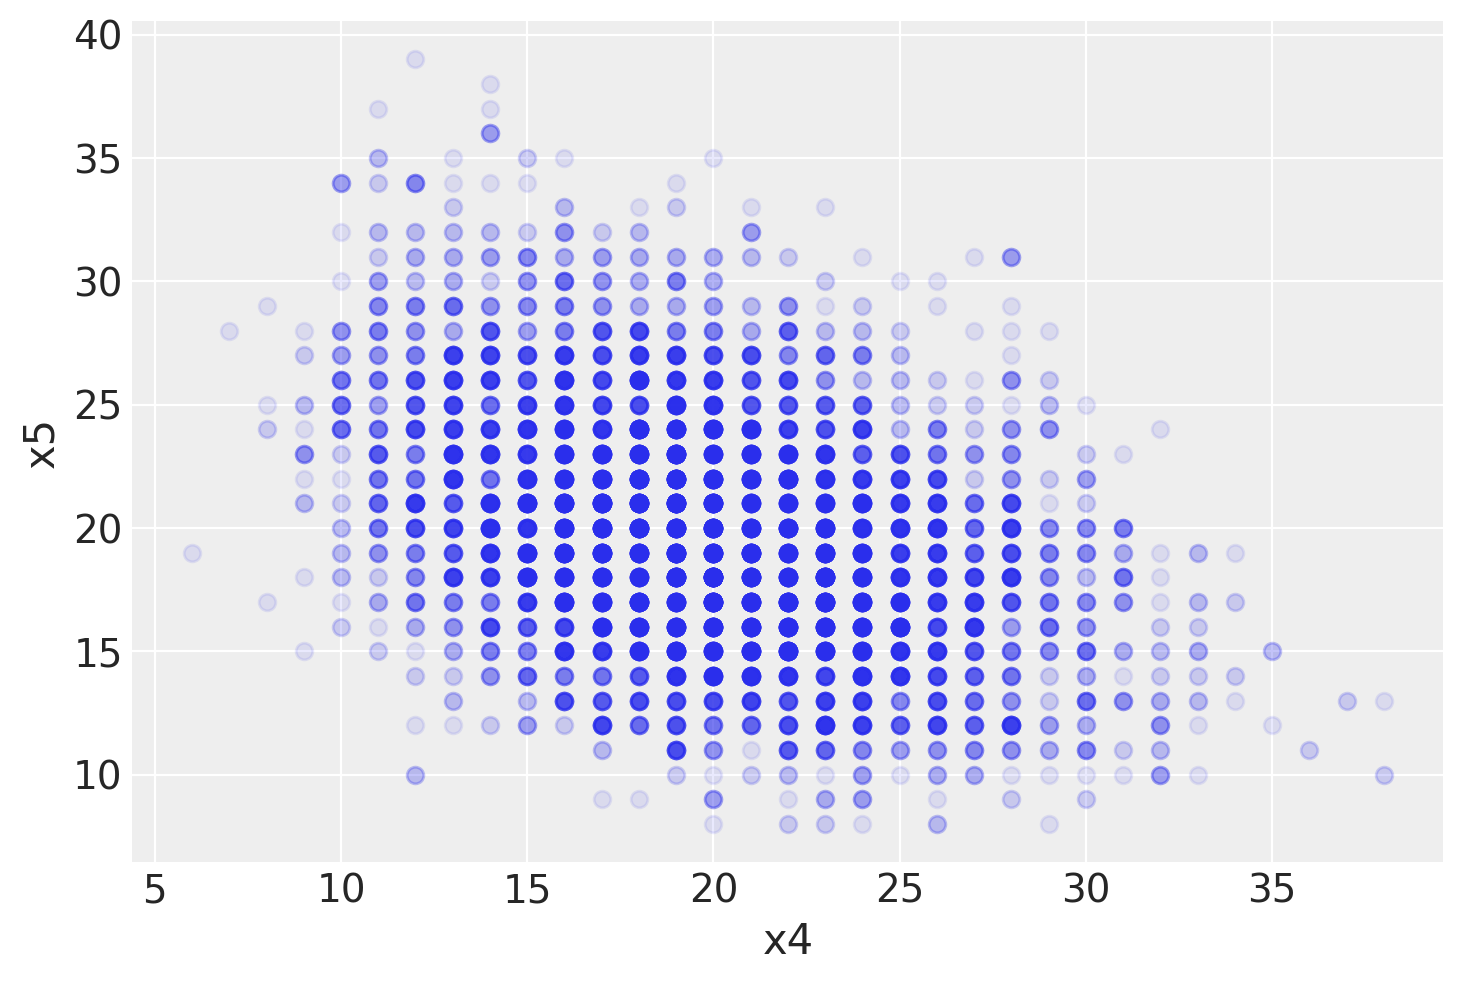

In [308]:
plt.scatter(trace.posterior['x4'].values.ravel(), trace.posterior['x5'].values.ravel(), alpha=0.1)
plt.xlabel('x4')
plt.ylabel('x5')

most probable values for x4 and x5 are somewhere around 20. They tend to be with negative relationship (if one is bigger other one is smaller